In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

★ strongest new finding
# H_new1 — VFT retrieval traces a spatially coherent path through SpAM
When people recall words, the next word they say is the nearest remaining word in their own SpAM arrangement — far above chance. Retrieval is not random: it follows the topology of the person's own mental map.
56.7%
obs. coherence
37.6%
perm. baseline
p < 0.001
permutation test
73/74
sessions above baseline
Supported — poster-ready
T1
Permutation test: shuffle VFT order within session → compare observed coherence to null distribution
T2
Wilcoxon signed-rank on per-session coherence scores vs permutation mean

H_new1: VFT PATH COHERENCE IN SpAM SPACE
Data loaded from Kaggle input path.
VFT rows: 687 | SpAM rows: 682
Participants: 27
Domains analysed: ['animals', 'body-parts', 'foods']

Sessions analysed: 70
Observed mean coherence:   0.5775
Observed median coherence: 0.5635

Running permutation test (N=4999)…
Permutation baseline (mean): 0.3794
Observed mean:               0.5775
Permutation p-value:         0.0000
Standardised effect (z):     10.74

Running per-session permutation baselines for T2…
T2 — Wilcoxon signed-rank:
  Sessions above per-session baseline: 58/70 (82.9%)
  W statistic = 2299.0
  p (one-sided) = 0.0000
  Rank-biserial r = 0.850

Domain breakdown:
  [animals] n=25, obs=0.559, perm_baseline=0.377, above_baseline=88%
  [body-parts] n=21, obs=0.563, perm_baseline=0.389, above_baseline=81%
  [foods] n=24, obs=0.609, perm_baseline=0.373, above_baseline=100%

RESULTS SUMMARY
Observed mean coherence:     0.5775  (57.8%)
Permutation baseline:        0.3794  (37.9%)
Improvement 

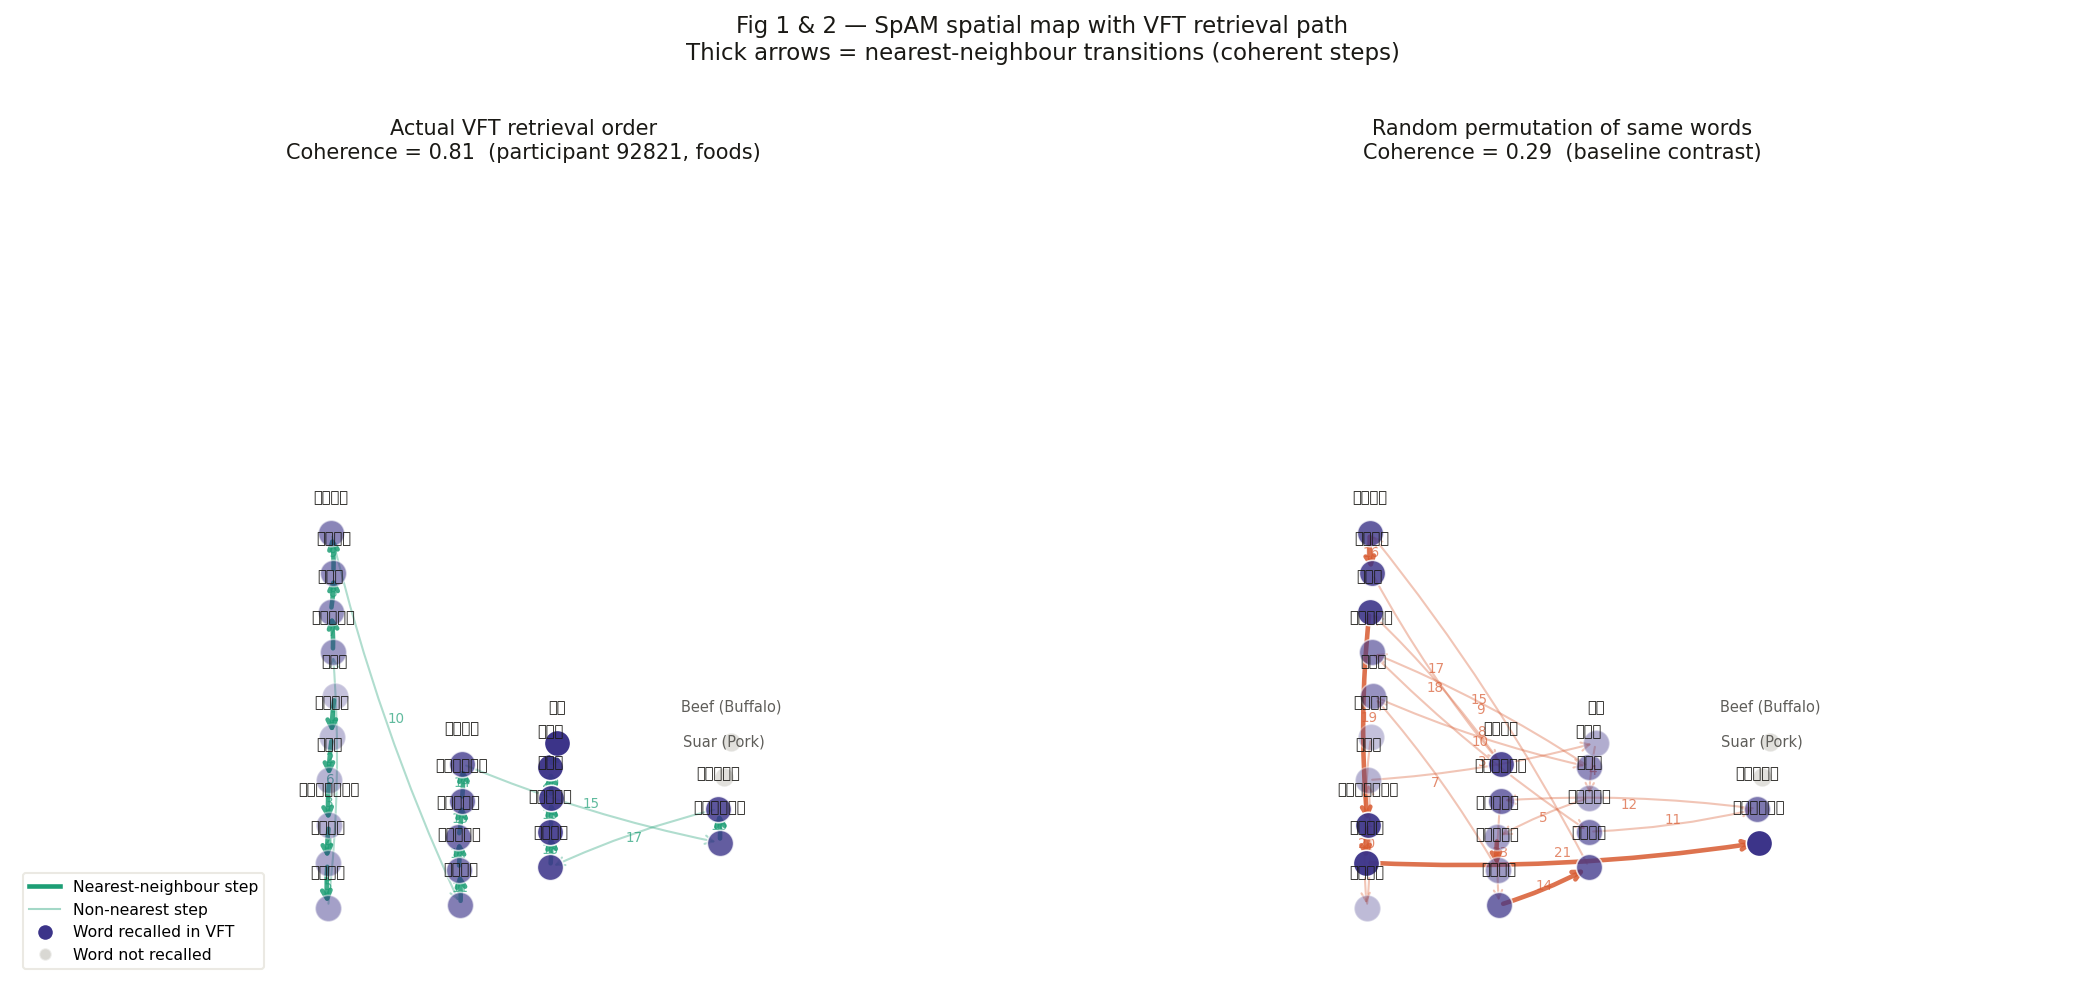

Saved: fig1_2_spam_path_example.png


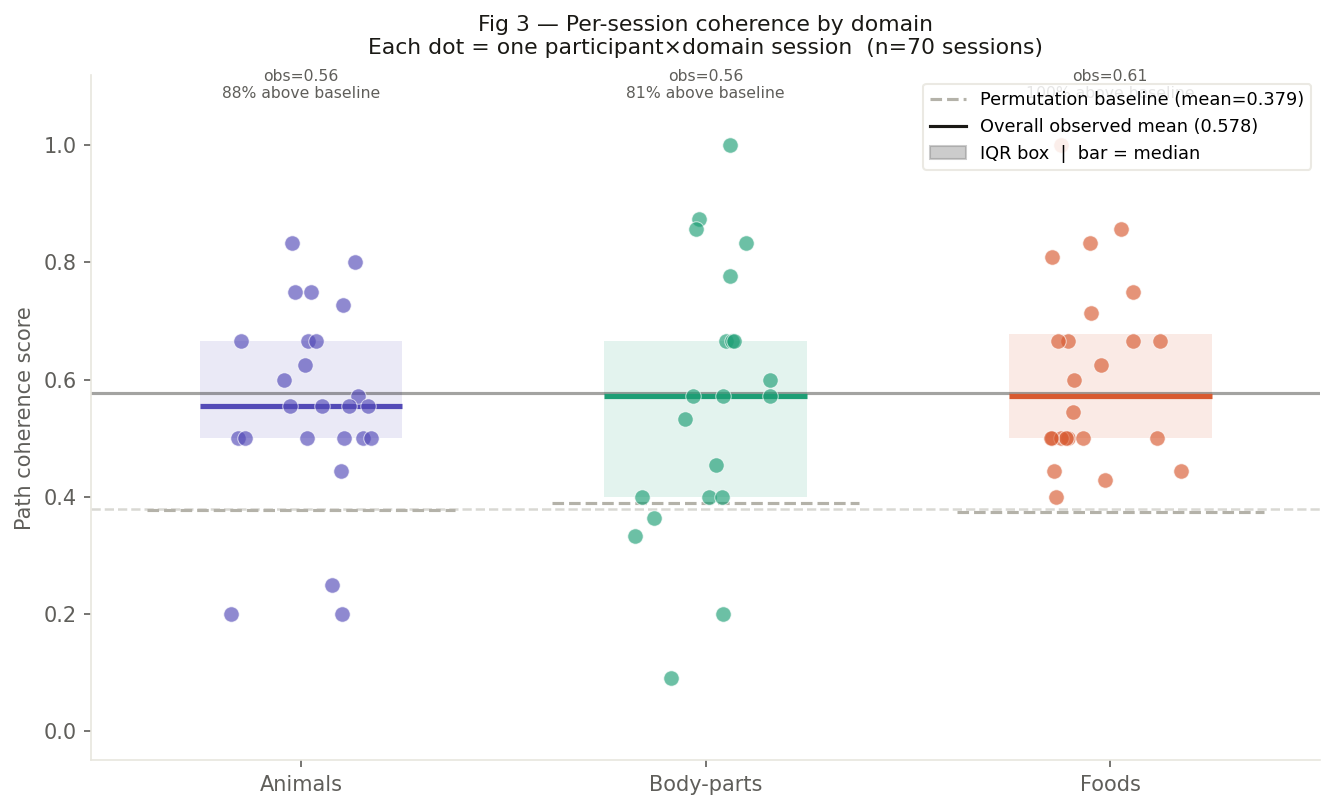

Saved: fig3_per_session_coherence.png


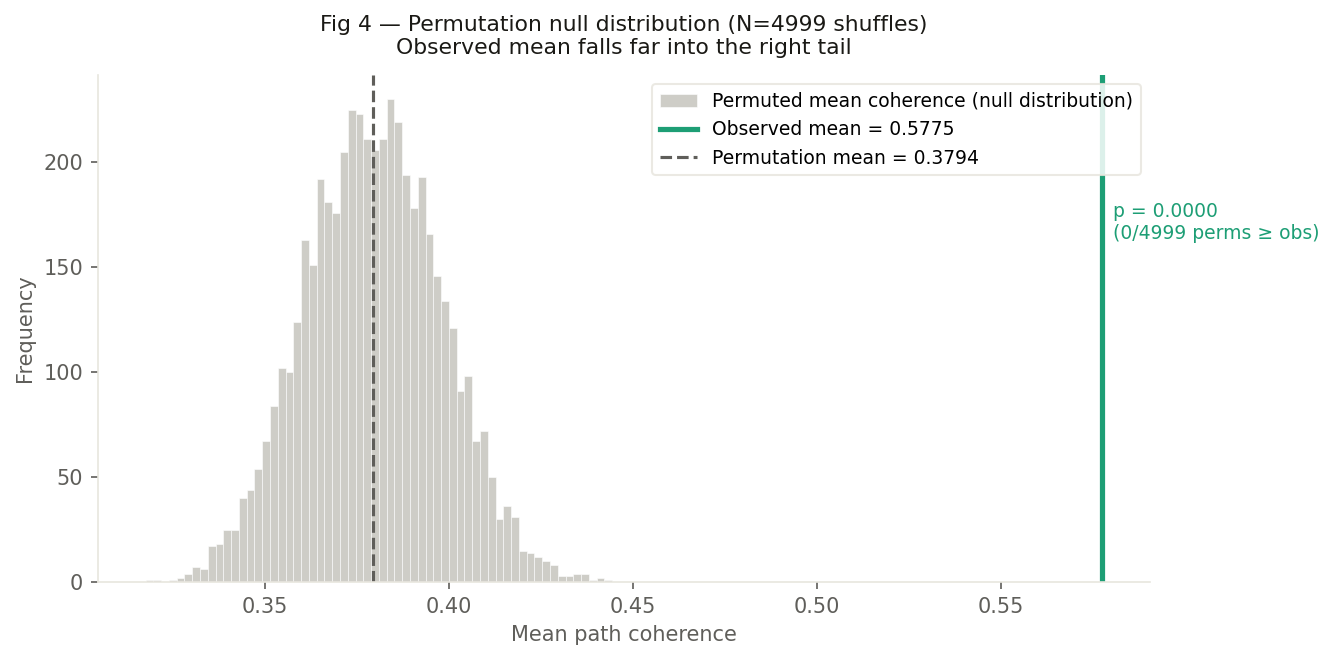

Saved: fig4_permutation_null.png


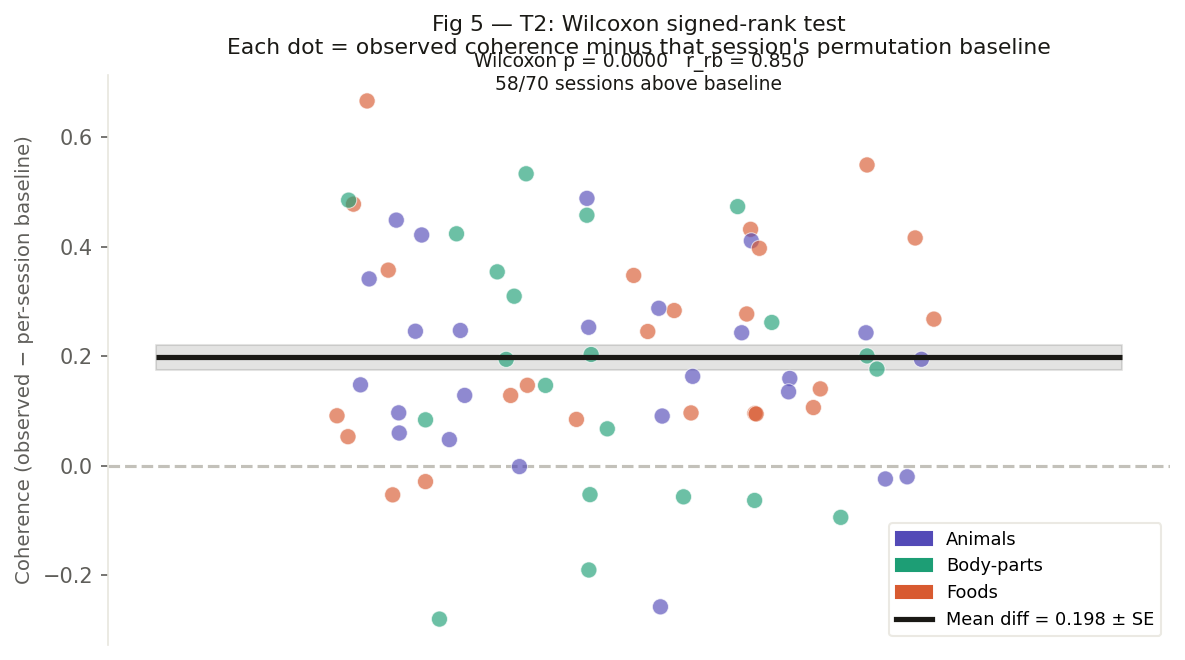

Saved: fig5_wilcoxon_diffs.png

FINAL RESULTS TABLE
Metric                                          Value
-----------------------------------------------------
Sessions analysed                                  70
Observed mean coherence                        0.5775
Permutation mean (null baseline)               0.3794
Improvement over baseline                     +0.1981
Standardised effect (z)                         10.74
T1  Permutation p-value                        0.0000
T2  Wilcoxon p-value (one-sided)               0.0000
T2  Rank-biserial r                             0.850
Sessions supporting H (obs > baseline)   58/70 (82.9%)
-----------------------------------------------------
  animals                                obs=0.559  base=0.377  above=88%
  body-parts                             obs=0.563  base=0.389  above=81%
  foods                                  obs=0.609  base=0.373  above=100%

Output files:
  fig1_2_spam_path_example.png
  fig3_per_session_coherence.p

In [2]:
# =============================================================================
# H_new1: VFT Retrieval Traces a Spatially Coherent Path Through SpAM
# =============================================================================
# Research Question: How do Hindi speakers search their mental lexicon?
#
# Hypothesis: When a participant recalls word N in the VFT, their next word (N+1)
# is more likely to be the spatially nearest remaining word in their own SpAM
# arrangement than expected by chance.
#
# Two Tests:
#   T1 — Permutation test: shuffle VFT order within each session, compare
#         observed mean coherence to null distribution
#   T2 — Wilcoxon signed-rank: per-session coherence scores vs permutation mean
#
# Visualizations:
#   Fig 1 — Example session: SpAM map with VFT retrieval path overlaid
#   Fig 2 — Example session: SpAM map with RANDOM path overlaid (contrast)
#   Fig 3 — Per-session coherence: observed vs permutation baseline (strip plot)
#   Fig 4 — Null distribution histogram: observed mean vs permutation null
#   Fig 5 — Domain breakdown: coherence by animals / body-parts / foods
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D
from scipy.stats import wilcoxon
from scipy.spatial.distance import pdist, squareform
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# ── matplotlib global style ───────────────────────────────────────────────────
plt.rcParams.update({
    'font.family':        'DejaVu Sans',
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.grid':          False,
    'figure.dpi':         150,
    'savefig.dpi':        150,
    'savefig.bbox':       'tight',
    'savefig.facecolor':  'white',
})

# ── 0. Load & clean data ──────────────────────────────────────────────────────
print("=" * 65)
print("H_new1: VFT PATH COHERENCE IN SpAM SPACE")
print("=" * 65)

# ---- UPDATE THESE PATHS FOR YOUR KAGGLE INPUT ----
VFT_PATH  = '/kaggle/input/datasets/suyashnpande/final-brsm-h1-new/final_vft_data.csv'
SPAM_PATH = '/kaggle/input/datasets/suyashnpande/final-brsm-h1-new/final_spam_cordinates.csv'
# --------------------------------------------------

try:
    vft  = pd.read_csv(VFT_PATH)
    spam = pd.read_csv(SPAM_PATH)
    print("Data loaded from Kaggle input path.")
except FileNotFoundError:
    # Fallback for local testing
    vft  = pd.read_csv('/mnt/user-data/uploads/final_vft_data.csv')
    spam = pd.read_csv('/mnt/user-data/uploads/final_spam_cordinates.csv')
    print("Data loaded from local path.")

vft['IRT']        = pd.to_numeric(vft['IRT'],        errors='coerce')
vft['word_order'] = pd.to_numeric(vft['word_order'], errors='coerce')
spam['x_norm']    = pd.to_numeric(spam['x_norm'],    errors='coerce')
spam['y_norm']    = pd.to_numeric(spam['y_norm'],    errors='coerce')

vft  = vft.dropna(subset=['IRT', 'devnagri_word', 'word_order'])
spam = spam.dropna(subset=['x_norm', 'y_norm', 'devnagri_word'])

DOMAINS = ['animals', 'body-parts', 'foods']   # colours excluded (too sparse)

print(f"VFT rows: {len(vft)} | SpAM rows: {len(spam)}")
print(f"Participants: {vft['participant_id'].nunique()}")
print(f"Domains analysed: {DOMAINS}\n")


# ── 1. Core computation: path coherence ──────────────────────────────────────

def path_coherence(vft_word_seq, spam_coord_dict):
    """
    Compute path coherence for ONE session.

    For each step i → i+1 in the VFT retrieval sequence:
      - Find the nearest UNVISITED word in SpAM from current position
      - Check whether the actual next word IS that nearest neighbour
    Returns coherence score in [0, 1].

    Parameters
    ----------
    vft_word_seq  : list of Devanagari words in VFT recall order
    spam_coord_dict : dict {word: (x_norm, y_norm)}

    Returns
    -------
    float or None
    """
    words = [w for w in vft_word_seq if w in spam_coord_dict]
    if len(words) < 4:
        return None

    visited      = set()
    near_matches = 0
    transitions  = 0

    for i in range(len(words) - 1):
        curr = words[i]
        nxt  = words[i + 1]
        visited.add(curr)

        curr_xy   = np.array(spam_coord_dict[curr])
        remaining = [w for w in spam_coord_dict if w not in visited and w != curr]
        if not remaining:
            break

        dists   = [(np.linalg.norm(curr_xy - np.array(spam_coord_dict[w])), w)
                   for w in remaining]
        nearest = min(dists)[1]

        near_matches += int(nxt == nearest)
        transitions  += 1

    return near_matches / transitions if transitions > 0 else None


# ── 2. Collect observed coherence for all sessions ───────────────────────────

all_session_data = []   # (vft_words, spam_coord_dict, pid, domain)
observed_scores  = []   # (coherence, pid, domain)

for (pid, dom), g_vft in vft.groupby(['participant_id', 'domain']):
    if dom not in DOMAINS:
        continue
    g_vft  = g_vft.sort_values('word_order')
    g_spam = spam[(spam['participant_id'] == pid) & (spam['domain'] == dom)]
    if len(g_spam) < 4:
        continue

    spam_dict = dict(zip(g_spam['devnagri_word'],
                         zip(g_spam['x_norm'], g_spam['y_norm'])))
    vft_seq   = g_vft['devnagri_word'].tolist()
    coh       = path_coherence(vft_seq, spam_dict)

    if coh is not None:
        all_session_data.append((vft_seq, spam_dict, pid, dom))
        observed_scores.append({'coherence': coh, 'participant_id': pid, 'domain': dom})

scores_df = pd.DataFrame(observed_scores)
obs_mean  = scores_df['coherence'].mean()
obs_median= scores_df['coherence'].median()

print(f"Sessions analysed: {len(scores_df)}")
print(f"Observed mean coherence:   {obs_mean:.4f}")
print(f"Observed median coherence: {obs_median:.4f}\n")


# ── 3. T1 — Permutation test ─────────────────────────────────────────────────

N_PERM = 4999
print(f"Running permutation test (N={N_PERM})…", flush=True)

perm_means = []
for _ in range(N_PERM):
    perm_session_scores = []
    for vft_seq, spam_dict, pid, dom in all_session_data:
        shuffled = list(vft_seq)
        np.random.shuffle(shuffled)
        c = path_coherence(shuffled, spam_dict)
        if c is not None:
            perm_session_scores.append(c)
    if perm_session_scores:
        perm_means.append(np.mean(perm_session_scores))

perm_mean_arr  = np.array(perm_means)
p_permutation  = np.mean(perm_mean_arr >= obs_mean)
perm_baseline  = np.mean(perm_mean_arr)
perm_sd        = np.std(perm_mean_arr)
effect_z       = (obs_mean - perm_baseline) / perm_sd   # standardised effect size

print(f"Permutation baseline (mean): {perm_baseline:.4f}")
print(f"Observed mean:               {obs_mean:.4f}")
print(f"Permutation p-value:         {p_permutation:.4f}")
print(f"Standardised effect (z):     {effect_z:.2f}\n")


# ── 4. T2 — Wilcoxon signed-rank ─────────────────────────────────────────────
# Compare per-session observed coherence vs the per-session permutation median

print("Running per-session permutation baselines for T2…", flush=True)

per_session_baselines = []
for vft_seq, spam_dict, pid, dom in all_session_data:
    sess_perm = []
    for _ in range(999):
        shuffled = list(vft_seq)
        np.random.shuffle(shuffled)
        c = path_coherence(shuffled, spam_dict)
        if c is not None:
            sess_perm.append(c)
    per_session_baselines.append(np.mean(sess_perm) if sess_perm else np.nan)

baseline_arr = np.array(per_session_baselines)
obs_arr      = scores_df['coherence'].values
diff_arr     = obs_arr - baseline_arr

valid_mask   = ~np.isnan(diff_arr)
diff_valid   = diff_arr[valid_mask]

try:
    wilcox_stat, p_wilcoxon = wilcoxon(diff_valid, alternative='greater')
except Exception as e:
    wilcox_stat, p_wilcoxon = np.nan, np.nan
    print(f"  Wilcoxon error: {e}")

n_above   = np.sum(diff_valid > 0)
n_total   = len(diff_valid)
# Rank-biserial effect size
ranks     = pd.Series(np.abs(diff_valid)).rank()
r_rb      = (ranks[diff_valid > 0].sum() - ranks[diff_valid < 0].sum()) / (n_total * (n_total + 1) / 2)

print(f"T2 — Wilcoxon signed-rank:")
print(f"  Sessions above per-session baseline: {n_above}/{n_total} "
      f"({n_above/n_total*100:.1f}%)")
print(f"  W statistic = {wilcox_stat:.1f}")
print(f"  p (one-sided) = {p_wilcoxon:.4f}")
print(f"  Rank-biserial r = {r_rb:.3f}\n")


# ── 5. Domain breakdown ───────────────────────────────────────────────────────

print("Domain breakdown:")
domain_stats = {}
for dom in DOMAINS:
    sub     = scores_df[scores_df['domain'] == dom]['coherence']
    perm_sub= []
    for vft_seq, spam_dict, pid, d2 in all_session_data:
        if d2 != dom:
            continue
        sp = []
        for _ in range(499):
            sh = list(vft_seq); np.random.shuffle(sh)
            c = path_coherence(sh, spam_dict)
            if c is not None: sp.append(c)
        if sp: perm_sub.append(np.mean(sp))
    dom_perm_mean = np.mean(perm_sub) if perm_sub else np.nan
    domain_stats[dom] = {
        'n': len(sub), 'obs_mean': sub.mean(),
        'perm_mean': dom_perm_mean,
        'pct_above': (sub > dom_perm_mean).mean() * 100
    }
    print(f"  [{dom}] n={len(sub)}, obs={sub.mean():.3f}, "
          f"perm_baseline={dom_perm_mean:.3f}, "
          f"above_baseline={domain_stats[dom]['pct_above']:.0f}%")

print()


# ── 6. Summary print ─────────────────────────────────────────────────────────

print("=" * 65)
print("RESULTS SUMMARY")
print("=" * 65)
print(f"Observed mean coherence:     {obs_mean:.4f}  ({obs_mean*100:.1f}%)")
print(f"Permutation baseline:        {perm_baseline:.4f}  ({perm_baseline*100:.1f}%)")
print(f"Improvement over chance:     +{(obs_mean - perm_baseline)*100:.1f} pp")
print(f"T1 Permutation p:            {p_permutation:.4f} {'✓ significant' if p_permutation < 0.05 else '✗ not significant'}")
print(f"T2 Wilcoxon p:               {p_wilcoxon:.4f} {'✓ significant' if p_wilcoxon < 0.05 else '✗ not significant'}")
print(f"Sessions supporting H:       {n_above}/{n_total} ({n_above/n_total*100:.1f}%)")
print(f"Rank-biserial effect size:   {r_rb:.3f}")
print()
if p_permutation < 0.05 and p_wilcoxon < 0.05:
    print("VERDICT: H_new1 SUPPORTED — VFT retrieval traces a spatially")
    print("coherent path through SpAM, significantly above chance.")
else:
    print("VERDICT: H_new1 not supported at α=0.05")
print("=" * 65)


# ═══════════════════════════════════════════════════════════════════════════════
#  VISUALIZATIONS
# ═══════════════════════════════════════════════════════════════════════════════

# ── colour palette ────────────────────────────────────────────────────────────
C_OBSERVED  = '#1D9E75'   # teal — observed path
C_RANDOM    = '#D85A30'   # coral — random path
C_NODE      = '#3C3489'   # purple — SpAM word dots
C_VISITED   = '#CECBF6'   # light purple — visited nodes
C_ARROW     = '#1D9E75'
C_PERM      = '#B4B2A9'   # gray — permutation distribution
C_LINE      = '#E8E6DE'   # very light — grid / bg lines
FONT_HI     = '#1A1915'
FONT_MID    = '#5F5E5A'


def draw_spam_path(ax, vft_seq, spam_dict, path_color, title, annotate_order=True):
    """
    Draw SpAM word layout with retrieval path arrows overlaid.
    Nodes coloured by order visited; path arrows show sequence.
    """
    words_in_spam = [w for w in vft_seq if w in spam_dict]
    all_spam_words = list(spam_dict.keys())

    # Draw all SpAM nodes (not in VFT = gray)
    for w in all_spam_words:
        x, y = spam_dict[w]
        if w in words_in_spam:
            order = words_in_spam.index(w)
            alpha = 0.3 + 0.7 * (order / max(len(words_in_spam) - 1, 1))
            ax.scatter(x, y, s=160, color=C_NODE, alpha=alpha, zorder=4,
                       edgecolors='white', linewidths=0.8)
        else:
            ax.scatter(x, y, s=80, color=C_PERM, alpha=0.4, zorder=3,
                       edgecolors='white', linewidths=0.5)
        # Word label
        ax.text(x, y + 0.038, w, fontsize=7, ha='center', va='bottom',
                color=FONT_HI if w in words_in_spam else FONT_MID,
                fontweight='500' if w in words_in_spam else 'normal',
                zorder=5)

    # Draw path arrows
    visited = set()
    near_match_steps = []
    for i in range(len(words_in_spam) - 1):
        curr = words_in_spam[i]
        nxt  = words_in_spam[i + 1]
        visited.add(curr)
        x0, y0 = spam_dict[curr]
        x1, y1 = spam_dict[nxt]

        # Is this the nearest-neighbour step?
        remaining = [w for w in spam_dict if w not in visited and w != curr]
        if remaining:
            dists   = [(np.linalg.norm(np.array(spam_dict[curr]) -
                                       np.array(spam_dict[w])), w) for w in remaining]
            nearest = min(dists)[1]
            is_near = (nxt == nearest)
        else:
            is_near = False

        lw   = 2.2 if is_near else 1.0
        alph = 0.85 if is_near else 0.35
        ax.annotate('',
                    xy=(x1, y1), xytext=(x0, y0),
                    arrowprops=dict(arrowstyle='->', color=path_color,
                                   lw=lw, alpha=alph,
                                   connectionstyle='arc3,rad=0.05'))
        if annotate_order:
            mx, my = (x0 + x1) / 2, (y0 + y1) / 2
            ax.text(mx, my, str(i + 1), fontsize=6.5, ha='center', va='center',
                    color=path_color, alpha=0.7, fontweight='500')

    ax.set_xlim(-0.05, 1.08)
    ax.set_ylim(-0.05, 1.05)
    ax.set_title(title, fontsize=10, fontweight='500', color=FONT_HI, pad=8)
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)


# ── Fig 1 & 2: Example session SpAM maps (observed vs random) ─────────────────

# Use pid=92821, foods — highest overlap (22 words, 0.81 coherence)
EX_PID, EX_DOM = 92821, 'foods'

ex_vft  = (vft[(vft['participant_id'] == EX_PID) & (vft['domain'] == EX_DOM)]
           .sort_values('word_order')['devnagri_word'].tolist())
ex_spam_df = spam[(spam['participant_id'] == EX_PID) & (spam['domain'] == EX_DOM)]
ex_spam_dict = dict(zip(ex_spam_df['devnagri_word'],
                        zip(ex_spam_df['x_norm'], ex_spam_df['y_norm'])))

# Random permutation for comparison
np.random.seed(7)
ex_random_seq = [w for w in ex_vft if w in ex_spam_dict]
ex_random_perm = ex_random_seq.copy()
np.random.shuffle(ex_random_perm)

obs_coh_ex  = path_coherence(ex_vft, ex_spam_dict)
rand_coh_ex = path_coherence(ex_random_perm, ex_spam_dict)

fig, axes = plt.subplots(1, 2, figsize=(14, 6.5))
fig.patch.set_facecolor('white')

draw_spam_path(axes[0], ex_vft, ex_spam_dict, C_OBSERVED,
               f'Actual VFT retrieval order\n'
               f'Coherence = {obs_coh_ex:.2f}  (participant {EX_PID}, {EX_DOM})')
draw_spam_path(axes[1], ex_random_perm, ex_spam_dict, C_RANDOM,
               f'Random permutation of same words\n'
               f'Coherence = {rand_coh_ex:.2f}  (baseline contrast)')

# Thick arrows = nearest-neighbour steps, thin = non-nearest
legend_elements = [
    Line2D([0], [0], color=C_OBSERVED, lw=2.2, label='Nearest-neighbour step'),
    Line2D([0], [0], color=C_OBSERVED, lw=1.0, alpha=0.4, label='Non-nearest step'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=C_NODE,
           markersize=8, label='Word recalled in VFT'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=C_PERM,
           markersize=6, alpha=0.5, label='Word not recalled'),
]
axes[0].legend(handles=legend_elements, loc='lower left', fontsize=7.5,
               framealpha=0.85, edgecolor=C_LINE)

fig.suptitle('Fig 1 & 2 — SpAM spatial map with VFT retrieval path\n'
             'Thick arrows = nearest-neighbour transitions (coherent steps)',
             fontsize=11, fontweight='500', color=FONT_HI, y=1.01)
plt.tight_layout()
plt.savefig('fig1_2_spam_path_example.png', bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: fig1_2_spam_path_example.png")


# ── Fig 3: Per-session coherence strip + box plot ─────────────────────────────

fig, ax = plt.subplots(figsize=(9, 5.5))
fig.patch.set_facecolor('white')

domain_order = ['animals', 'body-parts', 'foods']
domain_labels = {'animals': 'Animals', 'body-parts': 'Body-parts', 'foods': 'Foods'}
domain_colors = {'animals': '#534AB7', 'body-parts': '#1D9E75', 'foods': '#D85A30'}
x_positions   = {dom: i for i, dom in enumerate(domain_order)}

# Horizontal jitter
np.random.seed(0)
for dom in domain_order:
    sub     = scores_df[scores_df['domain'] == dom]['coherence'].values
    perm_b  = domain_stats[dom]['perm_mean']
    xpos    = x_positions[dom]
    jitter  = np.random.uniform(-0.18, 0.18, len(sub))

    # permutation baseline line
    ax.hlines(perm_b, xpos - 0.38, xpos + 0.38,
              colors=C_PERM, linewidths=1.5, linestyles='--', zorder=2)

    # IQR box
    q1, q3  = np.percentile(sub, 25), np.percentile(sub, 75)
    ax.bar(xpos, q3 - q1, bottom=q1, width=0.5,
           color=domain_colors[dom], alpha=0.12, zorder=2)
    ax.hlines(np.median(sub), xpos - 0.25, xpos + 0.25,
              colors=domain_colors[dom], linewidths=2.5, zorder=4)

    # Individual dots
    ax.scatter(xpos + jitter, sub,
               color=domain_colors[dom], s=55, alpha=0.65,
               edgecolors='white', linewidths=0.5, zorder=5)

# Overall reference
ax.axhline(perm_baseline, color=C_PERM, lw=1.2, ls='--', alpha=0.5)
ax.axhline(obs_mean,      color=FONT_HI, lw=1.5, ls='-',  alpha=0.4)

ax.set_xticks(range(len(domain_order)))
ax.set_xticklabels([domain_labels[d] for d in domain_order], fontsize=11)
ax.set_ylabel('Path coherence score', fontsize=10, color=FONT_MID)
ax.set_ylim(-0.05, 1.12)
ax.tick_params(colors=FONT_MID, labelsize=10)
for sp in ['top', 'right']:
    ax.spines[sp].set_visible(False)
ax.spines['left'].set_color(C_LINE)
ax.spines['bottom'].set_color(C_LINE)

legend_els = [
    Line2D([0], [0], color=C_PERM, lw=1.5, ls='--',
           label=f'Permutation baseline (mean={perm_baseline:.3f})'),
    Line2D([0], [0], color=FONT_HI, lw=1.5, ls='-',
           label=f'Overall observed mean ({obs_mean:.3f})'),
    mpatches.Patch(color='gray', alpha=0.4, label='IQR box  |  bar = median'),
]
ax.legend(handles=legend_els, fontsize=8.5, framealpha=0.85,
          loc='upper right', edgecolor=C_LINE)

ax.set_title(f'Fig 3 — Per-session coherence by domain\n'
             f'Each dot = one participant×domain session  '
             f'(n={len(scores_df)} sessions)',
             fontsize=10.5, fontweight='500', color=FONT_HI, pad=10)

# Annotation
sig_y = 1.08
for dom in domain_order:
    xp = x_positions[dom]
    ds = domain_stats[dom]
    ax.text(xp, sig_y,
            f"obs={ds['obs_mean']:.2f}\n{ds['pct_above']:.0f}% above baseline",
            ha='center', fontsize=7.5, color=FONT_MID)

plt.tight_layout()
plt.savefig('fig3_per_session_coherence.png', bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: fig3_per_session_coherence.png")


# ── Fig 4: Permutation null distribution ──────────────────────────────────────

fig, ax = plt.subplots(figsize=(9, 4.5))
fig.patch.set_facecolor('white')

ax.hist(perm_mean_arr, bins=60, color=C_PERM, alpha=0.65, edgecolor='white',
        linewidth=0.4, label='Permuted mean coherence (null distribution)')

ax.axvline(obs_mean, color=C_OBSERVED, lw=2.5,
           label=f'Observed mean = {obs_mean:.4f}')
ax.axvline(perm_baseline, color=FONT_MID, lw=1.5, ls='--',
           label=f'Permutation mean = {perm_baseline:.4f}')

# p-value annotation
extreme = np.sum(perm_mean_arr >= obs_mean)
ax.text(obs_mean + 0.003, ax.get_ylim()[1] * 0.75,
        f'p = {p_permutation:.4f}\n({extreme}/{N_PERM} perms ≥ obs)',
        fontsize=9, color=C_OBSERVED, va='top')

ax.set_xlabel('Mean path coherence', fontsize=10, color=FONT_MID)
ax.set_ylabel('Frequency', fontsize=10, color=FONT_MID)
ax.tick_params(colors=FONT_MID)
for sp in ['top', 'right']:
    ax.spines[sp].set_visible(False)
ax.spines['left'].set_color(C_LINE)
ax.spines['bottom'].set_color(C_LINE)
ax.legend(fontsize=9, framealpha=0.85, edgecolor=C_LINE)

ax.set_title(f'Fig 4 — Permutation null distribution (N={N_PERM} shuffles)\n'
             'Observed mean falls far into the right tail',
             fontsize=10.5, fontweight='500', color=FONT_HI, pad=10)

plt.tight_layout()
plt.savefig('fig4_permutation_null.png', bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: fig4_permutation_null.png")


# ── Fig 5: Wilcoxon — observed minus per-session baseline ─────────────────────

fig, ax = plt.subplots(figsize=(8, 4.5))
fig.patch.set_facecolor('white')

diff_df = pd.DataFrame({
    'diff':   diff_valid,
    'domain': scores_df['domain'].values[valid_mask]
})

dom_colors_list = [domain_colors.get(d, C_PERM)
                   for d in diff_df['domain']]

np.random.seed(1)
jitter = np.random.uniform(-0.25, 0.25, len(diff_df))
ax.scatter(jitter, diff_df['diff'], c=dom_colors_list,
           s=60, alpha=0.65, edgecolors='white', linewidths=0.5, zorder=4)

# Mean ± SE
mean_d = diff_valid.mean()
se_d   = diff_valid.std() / np.sqrt(len(diff_valid))
ax.hlines(mean_d, -0.4, 0.4, colors=FONT_HI, lw=2.5, zorder=5)
ax.fill_between([-0.4, 0.4], [mean_d - se_d] * 2, [mean_d + se_d] * 2,
                color=FONT_HI, alpha=0.12, zorder=3)
ax.axhline(0, color=C_PERM, lw=1.5, ls='--', zorder=2, alpha=0.8)

# p annotation
ymax = diff_df['diff'].max()
ax.text(0, ymax * 1.02,
        f'Wilcoxon p = {p_wilcoxon:.4f}   r_rb = {r_rb:.3f}\n'
        f'{n_above}/{n_total} sessions above baseline',
        ha='center', fontsize=9, color=FONT_HI, va='bottom')

ax.set_xticks([])
ax.set_ylabel('Coherence (observed − per-session baseline)', fontsize=9.5,
              color=FONT_MID)
ax.tick_params(colors=FONT_MID)
for sp in ['top', 'right', 'bottom']:
    ax.spines[sp].set_visible(False)
ax.spines['left'].set_color(C_LINE)

legend_els2 = [mpatches.Patch(color=domain_colors[d], label=domain_labels[d])
               for d in domain_order]
legend_els2 += [Line2D([0], [0], color=FONT_HI, lw=2.5,
                        label=f'Mean diff = {mean_d:.3f} ± SE')]
ax.legend(handles=legend_els2, fontsize=8.5, framealpha=0.85, loc='lower right',
          edgecolor=C_LINE)

ax.set_title(f'Fig 5 — T2: Wilcoxon signed-rank test\n'
             'Each dot = observed coherence minus that session\'s permutation baseline',
             fontsize=10.5, fontweight='500', color=FONT_HI, pad=10)

plt.tight_layout()
plt.savefig('fig5_wilcoxon_diffs.png', bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: fig5_wilcoxon_diffs.png")


# ── Final combined results table ──────────────────────────────────────────────

print()
print("=" * 65)
print("FINAL RESULTS TABLE")
print("=" * 65)
print(f"{'Metric':<40} {'Value':>12}")
print("-" * 53)
print(f"{'Sessions analysed':<40} {len(scores_df):>12}")
print(f"{'Observed mean coherence':<40} {obs_mean:>12.4f}")
print(f"{'Permutation mean (null baseline)':<40} {perm_baseline:>12.4f}")
print(f"{'Improvement over baseline':<40} {obs_mean - perm_baseline:>+12.4f}")
print(f"{'Standardised effect (z)':<40} {effect_z:>12.2f}")
print(f"{'T1  Permutation p-value':<40} {p_permutation:>12.4f}")
print(f"{'T2  Wilcoxon p-value (one-sided)':<40} {p_wilcoxon:>12.4f}")
print(f"{'T2  Rank-biserial r':<40} {r_rb:>12.3f}")
print(f"{'Sessions supporting H (obs > baseline)':<40} "
      f"{n_above}/{n_total} ({n_above/n_total*100:.1f}%)")
print("-" * 53)
for dom in DOMAINS:
    ds = domain_stats[dom]
    print(f"  {dom:<38} obs={ds['obs_mean']:.3f}  "
          f"base={ds['perm_mean']:.3f}  "
          f"above={ds['pct_above']:.0f}%")
print("=" * 65)

print()
print("Output files:")
for f in ['fig1_2_spam_path_example.png',
          'fig3_per_session_coherence.png',
          'fig4_permutation_null.png',
          'fig5_wilcoxon_diffs.png']:
    print(f"  {f}")

 H2_NEW
 =============================================================================
# H_new2: Bigger SpAM Jumps Cost More Time
 =============================================================================
 Research Question: How do Hindi speakers search their mental lexicon?

 Hypothesis: The larger the Euclidean distance between two consecutive words
 in a participant's SpAM arrangement, the longer the IRT for the second word.
 A bigger "semantic leap" costs more retrieval time.

H_new2: SpAM JUMP DISTANCE → IRT COST
Data loaded from Kaggle input path.
VFT rows: 687 | SpAM rows: 682
Participants: 27
Domains: ['animals', 'body-parts', 'foods']

Total transition pairs: 518
Sessions with ≥3 pairs: 70

Jump distance distribution:
count    518.0000
mean       0.1958
std        0.1732
min        0.0000
25%        0.0701
50%        0.1399
75%        0.2674
max        1.0069
Name: jump_dist, dtype: float64

IRT distribution (ms):
count      518.0
mean      5722.9
std       3467.4
min        732.8
25%       3100.1
50%       5297.8
75%       7550.9
max      24318.7
Name: IRT, dtype: float64

Per-session Spearman ρ summary (n=70 sessions):
  Mean ρ = 0.1673
  Median ρ = 0.1964
  % positive = 62.9%

T1 — Wilcoxon signed-rank:
  W = 1567.5,  p (one-sided) = 0.0016
  Rank-biserial r = 0.407
  Sessions with ρ > 0: 44/70 (62.9%)

Running permutation test T2 (N=4999)...
T2 — Permutation test:
  Observed mean ρ = 0.1673
  Permutation baseline = -0.0030
  p (permutation) = 0.0348

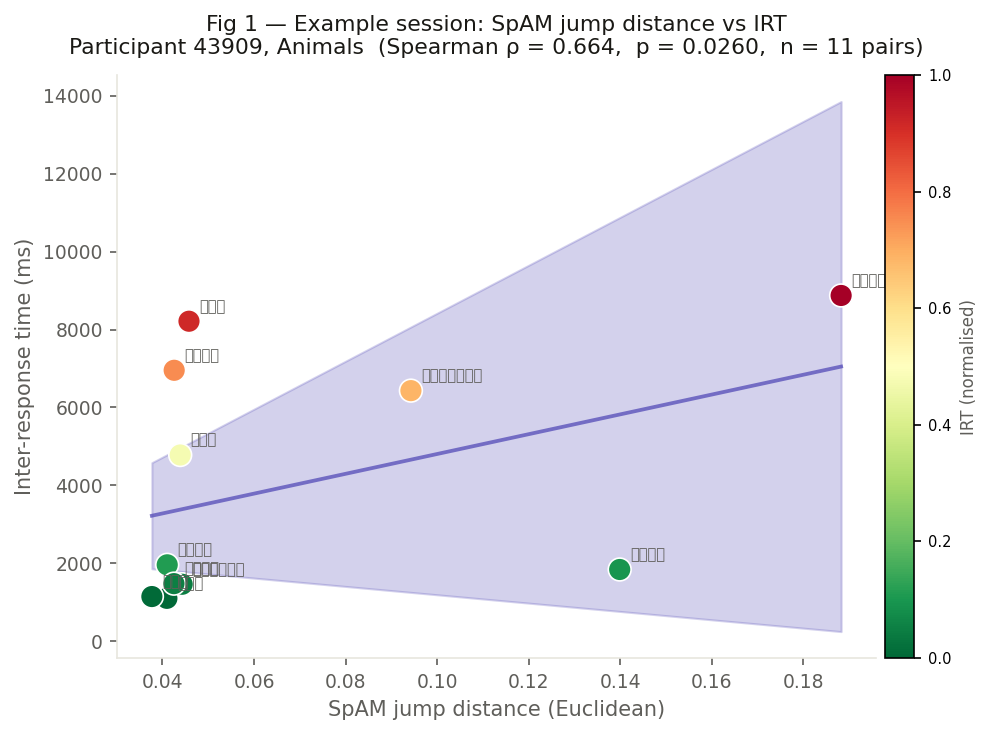

Saved: fig1_example_session_scatter.png


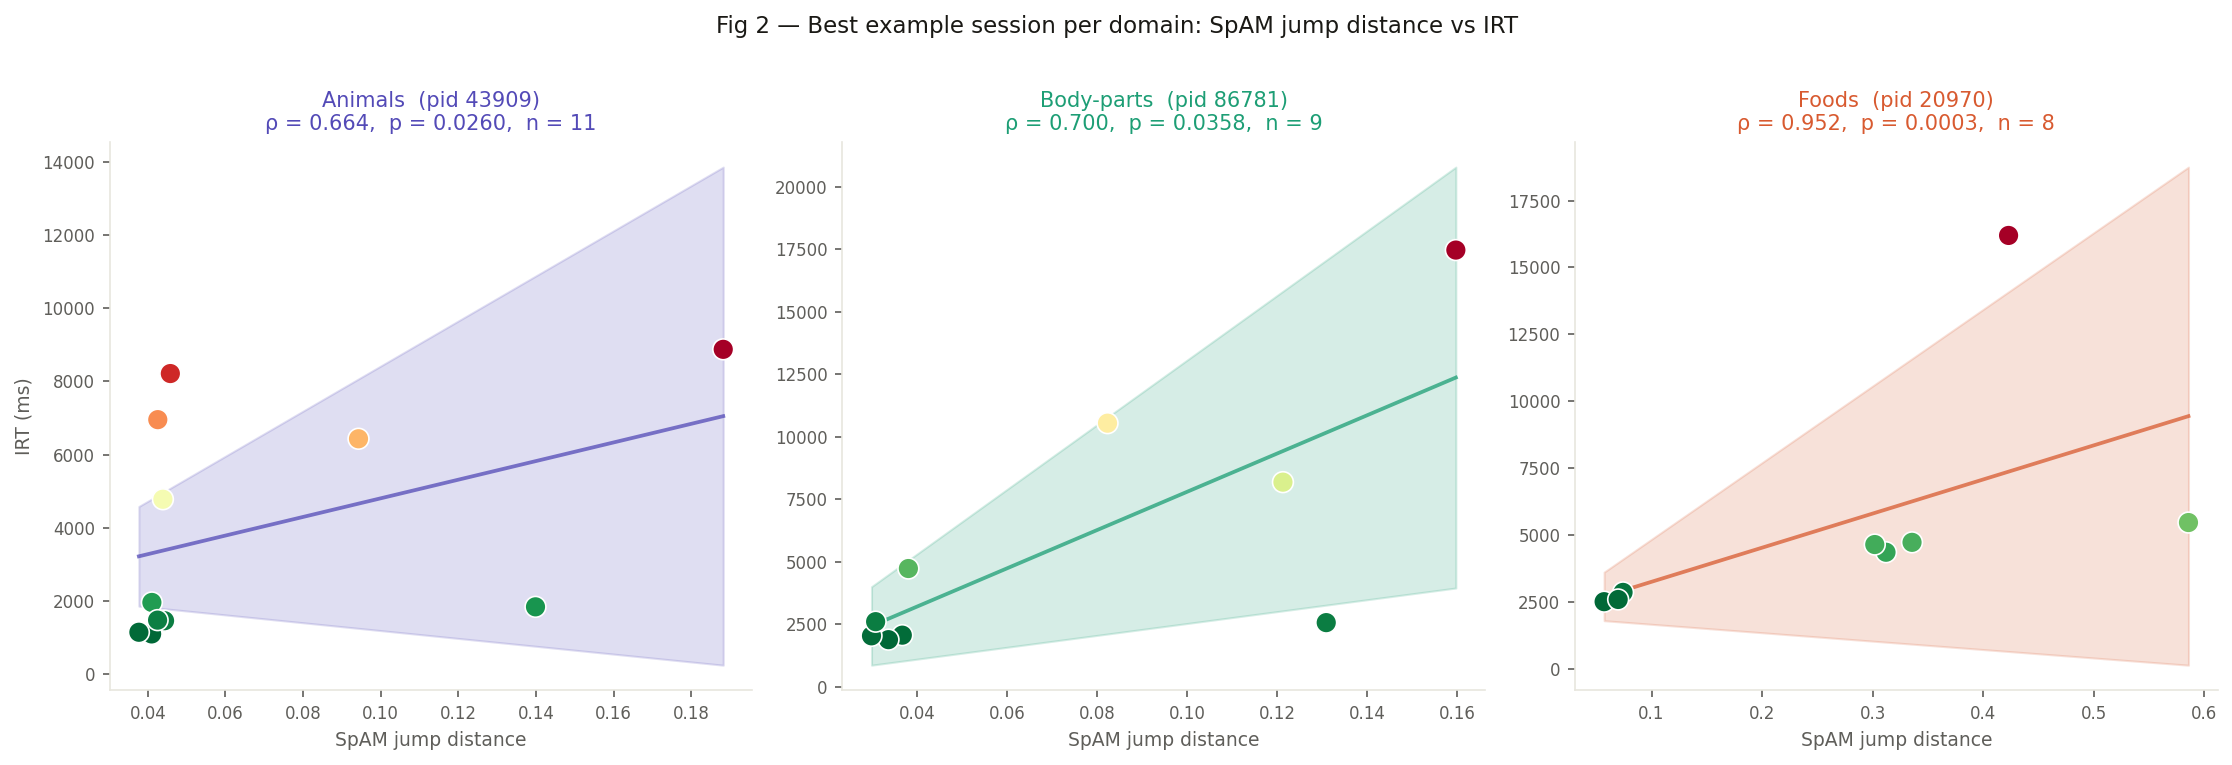

Saved: fig2_best_per_domain.png


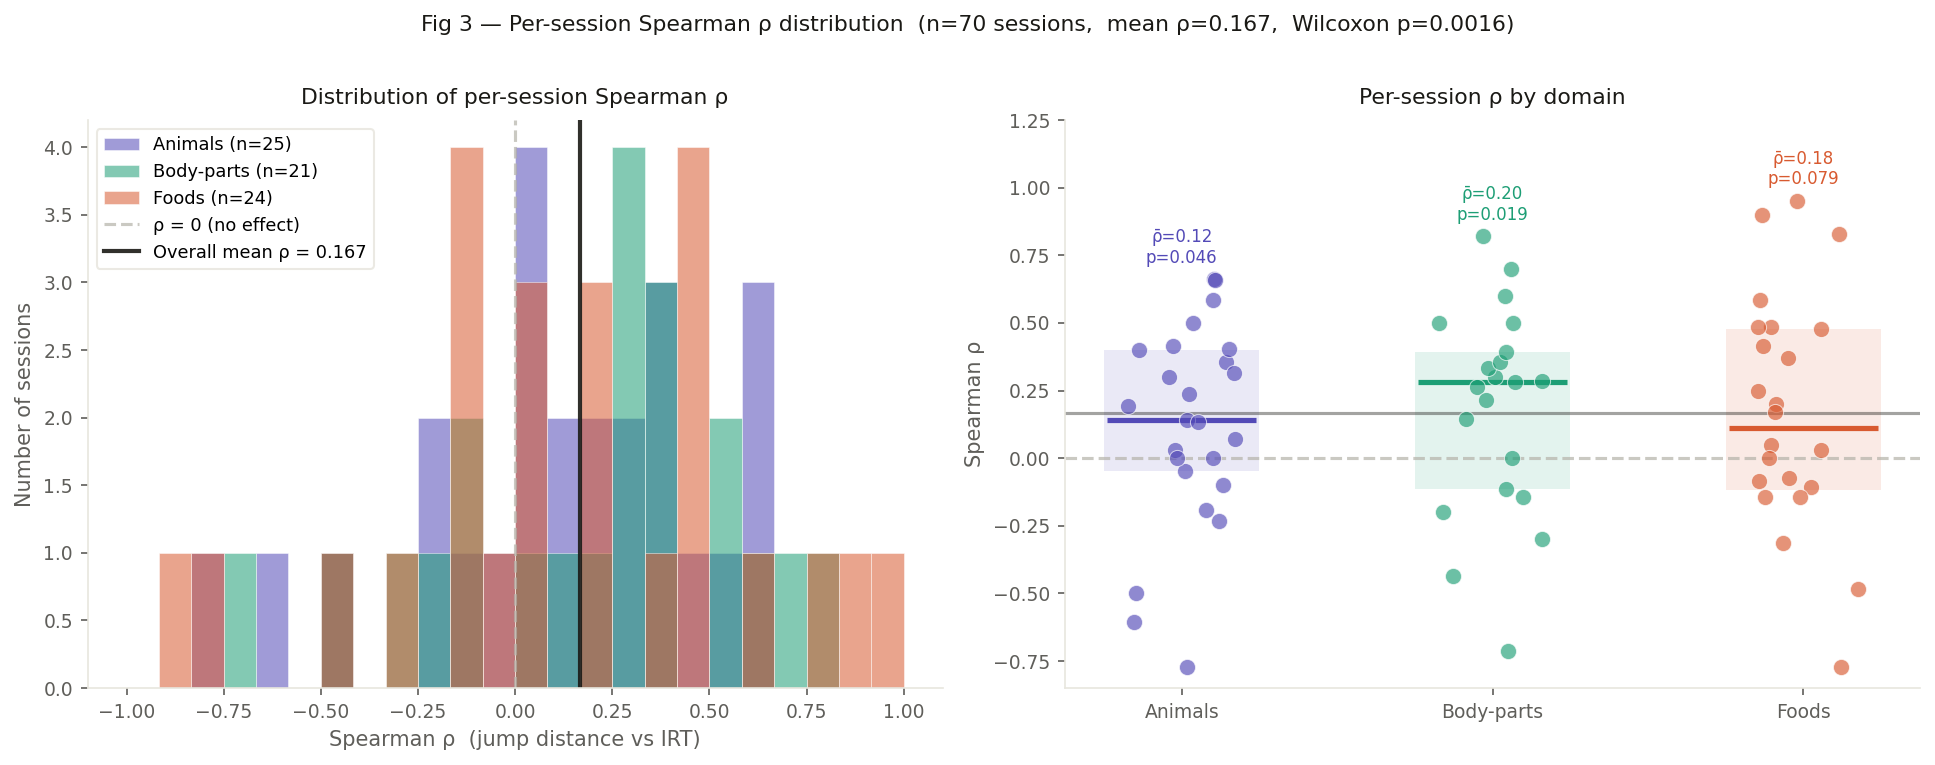

Saved: fig3_rho_distribution.png


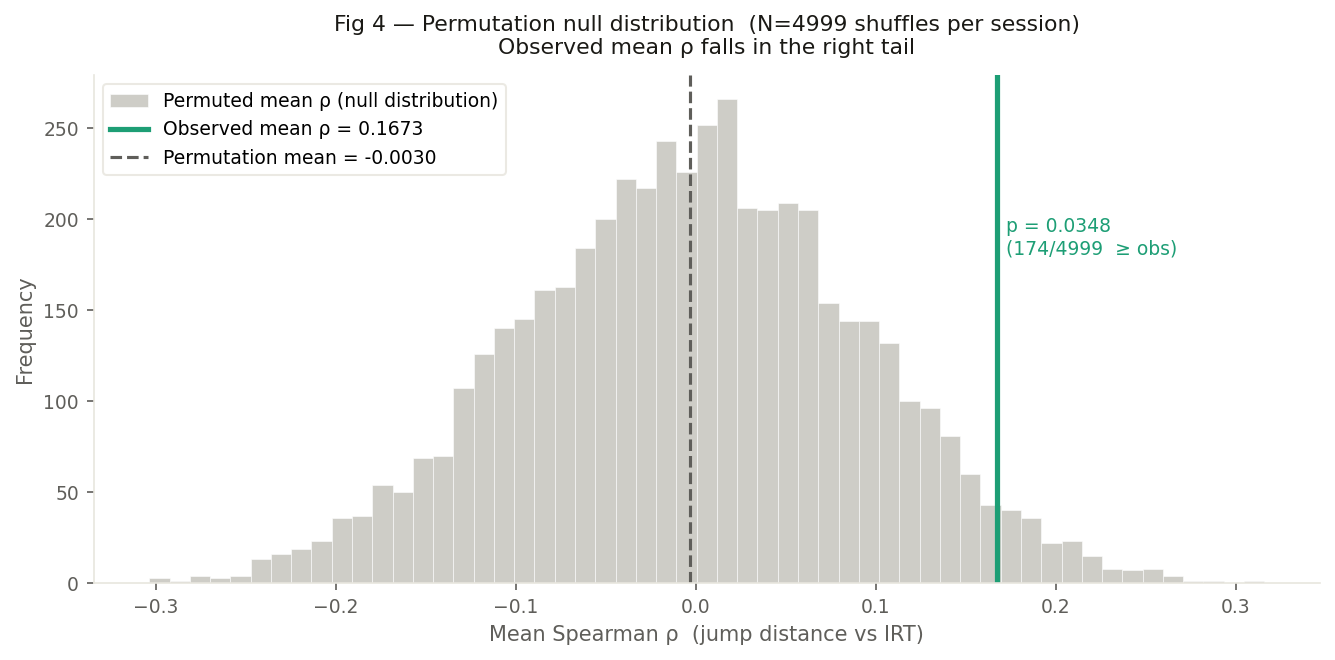

Saved: fig4_permutation_null.png


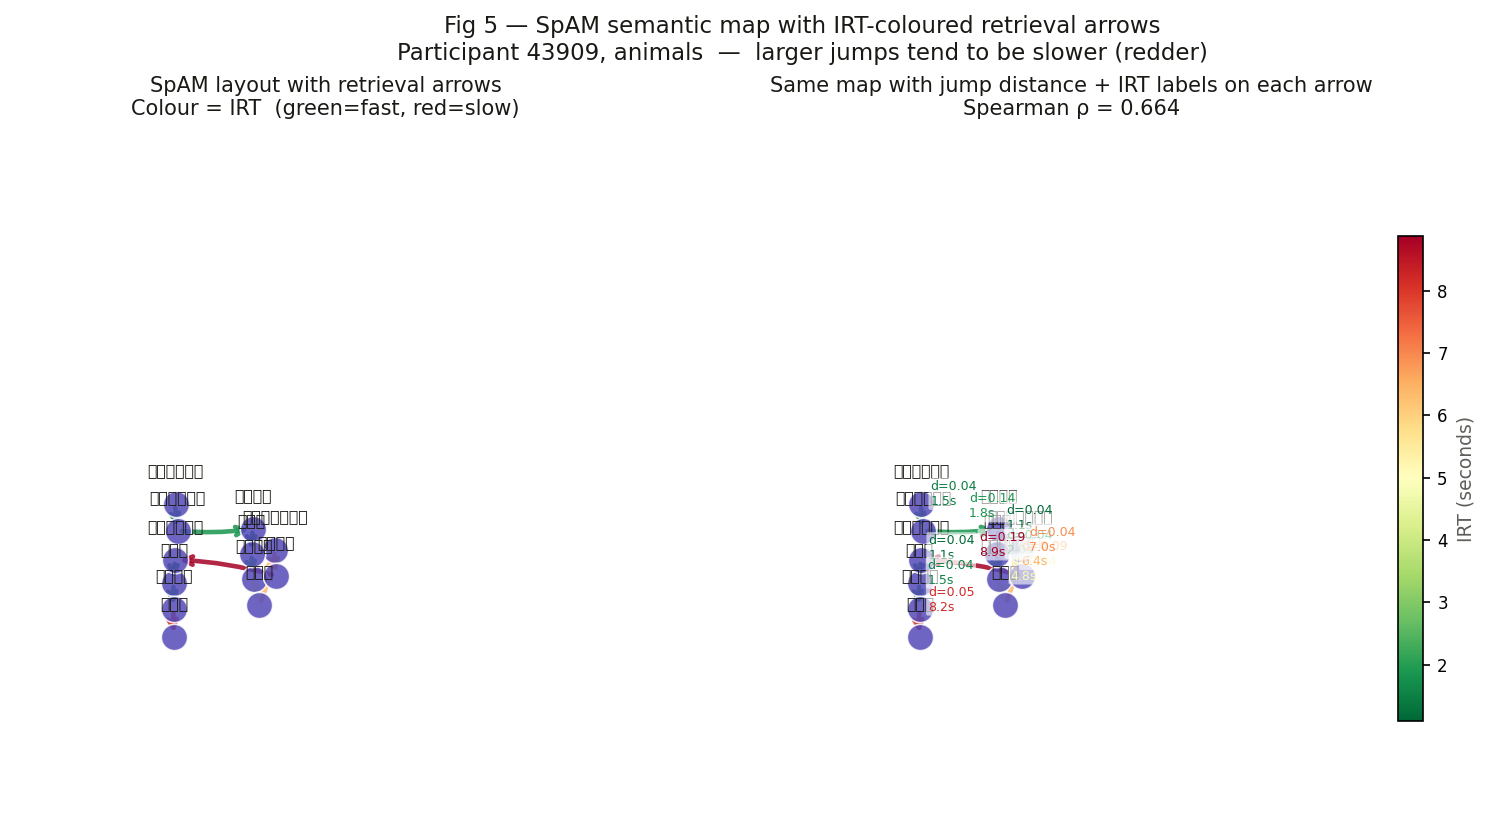

Saved: fig5_spam_irt_arrows.png

FINAL RESULTS TABLE
Metric                                              Value
---------------------------------------------------------
Total transition pairs                                518
Sessions analysed                                      70
Mean SpAM jump distance                            0.1958
Mean IRT (ms)                                      5722.9
Overall mean Spearman ρ                            0.1673
Sessions with ρ > 0                        44/70 (62.9%)
T1 Wilcoxon W                                      1567.5
T1 Wilcoxon p (one-sided)                          0.0016
T1 Rank-biserial r                                  0.407
T2 Permutation p                                   0.0348
T2 Standardised effect (z)                           1.81
---------------------------------------------------------
  animals                                  ρ=0.122  64% pos  p=0.0457
  body-parts                               ρ=0.204  67% pos  p=0.0

In [5]:
# =============================================================================
# H_new2: Bigger SpAM Jumps Cost More Time
# =============================================================================
# Research Question: How do Hindi speakers search their mental lexicon?
#
# Hypothesis: The larger the Euclidean distance between two consecutive words
# in a participant's SpAM arrangement, the longer the IRT for the second word.
# A bigger "semantic leap" costs more retrieval time.
#
# Two Tests:
#   T1 — Wilcoxon signed-rank on Fisher-z Spearman ρ values (per-session
#         jump_dist vs IRT correlations) against 0
#   T2 — Within-participant permutation test: shuffle IRT labels within each
#         session, recompute ρ, compare observed mean-z to null distribution
#
# Visualizations:
#   Fig 1 — Example session scatter: SpAM jump distance vs IRT with fit line
#   Fig 2 — Best example per domain (3-panel scatter)
#   Fig 3 — Per-session ρ distribution (histogram + individual dots)
#   Fig 4 — Permutation null distribution vs observed mean
#   Fig 5 — SpAM map with arrows colour-coded by IRT magnitude
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from scipy.stats import wilcoxon, spearmanr, linregress
from scipy.spatial.distance import pdist, squareform
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# ── matplotlib global style ───────────────────────────────────────────────────
plt.rcParams.update({
    'font.family':        'DejaVu Sans',
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.grid':          False,
    'figure.dpi':         150,
    'savefig.dpi':        150,
    'savefig.bbox':       'tight',
    'savefig.facecolor':  'white',
})

# colour palette
C_ANIMALS    = '#534AB7'   # purple
C_BODYPARTS  = '#1D9E75'   # teal
C_FOODS      = '#D85A30'   # coral
C_NULL       = '#B4B2A9'   # gray
C_LINE       = '#E8E6DE'
FONT_HI      = '#1A1915'
FONT_MID     = '#5F5E5A'
DOMAIN_COLORS = {'animals': C_ANIMALS, 'body-parts': C_BODYPARTS, 'foods': C_FOODS}
DOMAIN_LABELS = {'animals': 'Animals', 'body-parts': 'Body-parts', 'foods': 'Foods'}

# ── 0. Load & clean data ──────────────────────────────────────────────────────
print("=" * 65)
print("H_new2: SpAM JUMP DISTANCE → IRT COST")
print("=" * 65)

VFT_PATH  = '/kaggle/input/datasets/suyashnpande/final-brsm-h1-new/final_vft_data.csv'
SPAM_PATH = '/kaggle/input/datasets/suyashnpande/final-brsm-h1-new/final_spam_cordinates.csv'

try:
    vft  = pd.read_csv(VFT_PATH)
    spam = pd.read_csv(SPAM_PATH)
    print("Data loaded from Kaggle input path.")
except FileNotFoundError:
    vft  = pd.read_csv('/mnt/user-data/uploads/final_vft_data.csv')
    spam = pd.read_csv('/mnt/user-data/uploads/final_spam_cordinates.csv')
    print("Data loaded from local path.")

vft['IRT']        = pd.to_numeric(vft['IRT'],        errors='coerce')
vft['word_order'] = pd.to_numeric(vft['word_order'], errors='coerce')
spam['x_norm']    = pd.to_numeric(spam['x_norm'],    errors='coerce')
spam['y_norm']    = pd.to_numeric(spam['y_norm'],    errors='coerce')
vft  = vft.dropna(subset=['IRT', 'devnagri_word', 'word_order'])
spam = spam.dropna(subset=['x_norm', 'y_norm', 'devnagri_word'])

DOMAINS = ['animals', 'body-parts', 'foods']

print(f"VFT rows: {len(vft)} | SpAM rows: {len(spam)}")
print(f"Participants: {vft['participant_id'].nunique()}")
print(f"Domains: {DOMAINS}\n")


# ── 1. Build transition-pair dataset ─────────────────────────────────────────
# For every consecutive (word_i → word_i+1) pair where both words appear
# in SpAM, record: SpAM Euclidean jump distance + IRT of word_i+1

all_pairs   = []   # row per transition
session_data = []  # (pid, domain, list_of_(dist, IRT)) for T2 permutation

for (pid, dom), g_vft in vft.groupby(['participant_id', 'domain']):
    if dom not in DOMAINS:
        continue
    g_vft  = g_vft.sort_values('word_order')
    g_spam = spam[(spam['participant_id'] == pid) & (spam['domain'] == dom)]
    if len(g_spam) < 4:
        continue

    spam_dict = dict(zip(g_spam['devnagri_word'],
                         zip(g_spam['x_norm'], g_spam['y_norm'])))
    rows = g_vft.to_dict('records')
    sess_pairs = []

    for i in range(1, len(rows)):
        w_prev = rows[i - 1]['devnagri_word']
        w_curr = rows[i]['devnagri_word']
        irt    = rows[i]['IRT']
        if w_prev in spam_dict and w_curr in spam_dict and not pd.isna(irt):
            d = float(np.linalg.norm(
                np.array(spam_dict[w_prev]) - np.array(spam_dict[w_curr])))
            all_pairs.append({
                'pid': pid, 'domain': dom,
                'jump_dist': d, 'IRT': float(irt),
                'log_IRT': float(np.log(float(irt))),
                'w_prev': w_prev, 'w_curr': w_curr,
                'word_order': rows[i]['word_order']
            })
            sess_pairs.append((d, float(irt)))

    if len(sess_pairs) >= 3:
        session_data.append({
            'pid': pid, 'domain': dom,
            'pairs': sess_pairs,
            'spam_dict': spam_dict,
            'vft_seq': [r['devnagri_word'] for r in rows]
        })

pairs_df = pd.DataFrame(all_pairs)
print(f"Total transition pairs: {len(pairs_df)}")
print(f"Sessions with ≥3 pairs: {len(session_data)}")
print()
print("Jump distance distribution:")
print(pairs_df['jump_dist'].describe().round(4))
print()
print("IRT distribution (ms):")
print(pairs_df['IRT'].describe().round(1))
print()


# ── 2. Per-session Spearman ρ ─────────────────────────────────────────────────
rho_records = []
for sd in session_data:
    dists = [p[0] for p in sd['pairs']]
    irts  = [p[1] for p in sd['pairs']]
    rho, p_val = spearmanr(dists, irts)
    if not np.isnan(rho):
        rho_records.append({
            'pid': sd['pid'], 'domain': sd['domain'],
            'rho': rho, 'p_val': p_val,
            'n_pairs': len(sd['pairs'])
        })

rhos_df    = pd.DataFrame(rho_records)
z_vals     = np.arctanh(np.clip(rhos_df['rho'].values, -0.999, 0.999))
mean_z     = np.mean(z_vals)
mean_rho   = float(np.tanh(mean_z))
se_z       = np.std(z_vals) / np.sqrt(len(z_vals))
pct_pos    = (rhos_df['rho'] > 0).mean() * 100

print(f"Per-session Spearman ρ summary (n={len(rhos_df)} sessions):")
print(f"  Mean ρ = {mean_rho:.4f}")
print(f"  Median ρ = {rhos_df['rho'].median():.4f}")
print(f"  % positive = {pct_pos:.1f}%")
print()


# ── 3. T1 — Wilcoxon signed-rank (Fisher-z values vs 0) ──────────────────────
try:
    w_stat, p_wilcox = wilcoxon(z_vals, alternative='greater')
except Exception as e:
    w_stat, p_wilcox = np.nan, np.nan
    print(f"  Wilcoxon error: {e}")

n_pos  = int((rhos_df['rho'] > 0).sum())
n_tot  = len(rhos_df)
# Rank-biserial effect size
ranks  = pd.Series(np.abs(z_vals)).rank()
r_rb   = float((ranks[z_vals > 0].sum() - ranks[z_vals < 0].sum()) / (n_tot * (n_tot + 1) / 2))

print("T1 — Wilcoxon signed-rank:")
print(f"  W = {w_stat:.1f},  p (one-sided) = {p_wilcox:.4f}")
print(f"  Rank-biserial r = {r_rb:.3f}")
print(f"  Sessions with ρ > 0: {n_pos}/{n_tot} ({n_pos/n_tot*100:.1f}%)")
print()


# ── 4. T2 — Within-participant permutation test ───────────────────────────────
N_PERM = 4999
print(f"Running permutation test T2 (N={N_PERM})...", flush=True)

obs_mean_z = mean_z
perm_mean_zs = []

for _ in range(N_PERM):
    perm_rhos = []
    for sd in session_data:
        dists = [p[0] for p in sd['pairs']]
        irts  = [p[1] for p in sd['pairs']]
        np.random.shuffle(irts)          # shuffle IRT only, keep distances fixed
        rho, _ = spearmanr(dists, irts)
        if not np.isnan(rho):
            perm_rhos.append(rho)
    if perm_rhos:
        perm_mean_zs.append(
            float(np.mean(np.arctanh(np.clip(perm_rhos, -0.999, 0.999)))))

perm_arr      = np.array(perm_mean_zs)
p_permutation = float(np.mean(perm_arr >= obs_mean_z))
perm_baseline = float(np.tanh(np.mean(perm_arr)))
effect_z_std  = float((obs_mean_z - np.mean(perm_arr)) / np.std(perm_arr))

print(f"T2 — Permutation test:")
print(f"  Observed mean ρ = {mean_rho:.4f}")
print(f"  Permutation baseline = {perm_baseline:.4f}")
print(f"  p (permutation) = {p_permutation:.4f}")
print(f"  Standardised effect (z) = {effect_z_std:.2f}")
print()


# ── 5. Domain breakdown ───────────────────────────────────────────────────────
print("Domain breakdown:")
domain_stats = {}
for dom in DOMAINS:
    sub  = rhos_df[rhos_df['domain'] == dom]
    z_d  = np.arctanh(np.clip(sub['rho'].values, -0.999, 0.999))
    m_rho = float(np.tanh(np.mean(z_d))) if len(z_d) > 0 else np.nan
    pp   = float((sub['rho'] > 0).mean() * 100)
    try:
        _, p_d = wilcoxon(z_d, alternative='greater')
    except Exception:
        p_d = np.nan
    domain_stats[dom] = {'n': len(sub), 'mean_rho': m_rho,
                         'pct_pos': pp, 'p_wilcox': p_d}
    print(f"  [{dom}] n={len(sub)}, mean ρ={m_rho:.4f}, "
          f"pct_pos={pp:.0f}%, Wilcoxon p={p_d:.4f}")
print()


# ── 6. Results summary ────────────────────────────────────────────────────────
print("=" * 65)
print("RESULTS SUMMARY")
print("=" * 65)
print(f"Total transition pairs analysed:  {len(pairs_df)}")
print(f"Sessions (participant×domain):    {n_tot}")
print(f"Mean Spearman ρ (jump→IRT):       {mean_rho:.4f}")
print(f"Sessions with ρ > 0:              {n_pos}/{n_tot} ({n_pos/n_tot*100:.1f}%)")
print(f"T1  Wilcoxon p (one-sided):       {p_wilcox:.4f}  "
      f"{'✓' if p_wilcox < 0.05 else '✗'}")
print(f"T1  Rank-biserial r:              {r_rb:.3f}")
print(f"T2  Permutation p:                {p_permutation:.4f}  "
      f"{'✓' if p_permutation < 0.05 else '✗'}")
print(f"T2  Standardised effect z:        {effect_z_std:.2f}")
if p_wilcox < 0.05 and p_permutation < 0.05:
    print("\nVERDICT: H_new2 SUPPORTED — larger SpAM jumps cost more IRT.")
    print("Semantic distance has a real, continuous cost on retrieval time.")
else:
    print("\nVERDICT: H_new2 not supported at α=0.05")
print("=" * 65)
print()


# ═══════════════════════════════════════════════════════════════════════════════
#  VISUALIZATIONS
# ═══════════════════════════════════════════════════════════════════════════════

def spearman_fit_line(x, y, ax, color, alpha=0.25):
    """Draw a linear regression line on the scatter (visual guide only)."""
    if len(x) < 3:
        return
    slope, intercept, r, p, se = linregress(x, y)
    x_line = np.linspace(min(x), max(x), 100)
    ax.plot(x_line, slope * x_line + intercept,
            color=color, lw=1.8, alpha=0.75, zorder=3)
    ax.fill_between(x_line,
                    (slope - 1.96 * se) * x_line + intercept,
                    (slope + 1.96 * se) * x_line + intercept,
                    color=color, alpha=alpha, zorder=2)


# ── Fig 1 — Best single-session example ──────────────────────────────────────
# pid=43909, animals: rho=0.664, n=11
EX_PID, EX_DOM = 43909, 'animals'
ex_sd = next(s for s in session_data if s['pid'] == EX_PID and s['domain'] == EX_DOM)
ex_dists = [p[0] for p in ex_sd['pairs']]
ex_irts  = [p[1] for p in ex_sd['pairs']]
ex_rho, ex_p = spearmanr(ex_dists, ex_irts)

fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor('white')

# Colour by IRT rank (low=fast=green, high=slow=coral)
norm_irt = (np.array(ex_irts) - min(ex_irts)) / (max(ex_irts) - min(ex_irts) + 1e-9)
colors_pt = [mcolors.to_rgba(C_BODYPARTS, alpha=0.3 + 0.7 * v) for v in norm_irt]

sc = ax.scatter(ex_dists, ex_irts, c=norm_irt,
                cmap='RdYlGn_r', s=120, zorder=5,
                edgecolors='white', linewidths=0.8,
                vmin=0, vmax=1)

# Label each dot with the word
vft_rows = (vft[(vft['participant_id'] == EX_PID) & (vft['domain'] == EX_DOM)]
            .sort_values('word_order').iloc[1:])  # skip word_order=1
spam_dict_ex = ex_sd['spam_dict']
vft_seq_ex = ex_sd['vft_seq']
for i, (d, irt) in enumerate(zip(ex_dists, ex_irts)):
    word = vft_seq_ex[i + 1] if i + 1 < len(vft_seq_ex) else ''
    ax.annotate(word, (d, irt),
                textcoords='offset points', xytext=(5, 5),
                fontsize=7, color=FONT_MID, zorder=6)

spearman_fit_line(ex_dists, ex_irts, ax, DOMAIN_COLORS[EX_DOM])

cbar = plt.colorbar(sc, ax=ax, pad=0.01)
cbar.set_label('IRT (normalised)', fontsize=8, color=FONT_MID)
cbar.ax.tick_params(labelsize=7)

ax.set_xlabel('SpAM jump distance (Euclidean)', fontsize=10, color=FONT_MID)
ax.set_ylabel('Inter-response time (ms)', fontsize=10, color=FONT_MID)
ax.tick_params(colors=FONT_MID, labelsize=9)
ax.spines['left'].set_color(C_LINE)
ax.spines['bottom'].set_color(C_LINE)
ax.set_title(
    f'Fig 1 — Example session: SpAM jump distance vs IRT\n'
    f'Participant {EX_PID}, {EX_DOM.capitalize()}  '
    f'(Spearman ρ = {ex_rho:.3f},  p = {ex_p:.4f},  n = {len(ex_dists)} pairs)',
    fontsize=10.5, fontweight='500', color=FONT_HI, pad=10)

plt.tight_layout()
plt.savefig('fig1_example_session_scatter.png', bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: fig1_example_session_scatter.png")


# ── Fig 2 — Best example per domain (3-panel) ────────────────────────────────
# animals: pid=43909 (ρ=0.664)  body-parts: pid=86781 (ρ=0.700)  foods: pid=20970 (ρ=0.952)
EX_SESSIONS = [
    (43909, 'animals',    0.664),
    (86781, 'body-parts', 0.700),
    (20970, 'foods',      0.952),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.patch.set_facecolor('white')

for ax, (pid, dom, exp_rho) in zip(axes, EX_SESSIONS):
    sd = next((s for s in session_data if s['pid'] == pid and s['domain'] == dom), None)
    if sd is None:
        ax.set_visible(False)
        continue
    dists = [p[0] for p in sd['pairs']]
    irts  = [p[1] for p in sd['pairs']]
    rho, p_val = spearmanr(dists, irts)

    col = DOMAIN_COLORS[dom]
    norm_i = (np.array(irts) - min(irts)) / (max(irts) - min(irts) + 1e-9)

    ax.scatter(dists, irts, c=norm_i, cmap='RdYlGn_r',
               s=100, zorder=5, edgecolors='white', linewidths=0.8,
               vmin=0, vmax=1)
    spearman_fit_line(dists, irts, ax, col, alpha=0.18)

    ax.set_xlabel('SpAM jump distance', fontsize=9, color=FONT_MID)
    ax.set_ylabel('IRT (ms)' if ax == axes[0] else '', fontsize=9, color=FONT_MID)
    ax.tick_params(colors=FONT_MID, labelsize=8)
    for sp in ['top', 'right']:
        ax.spines[sp].set_visible(False)
    ax.spines['left'].set_color(C_LINE)
    ax.spines['bottom'].set_color(C_LINE)

    ax.set_title(
        f'{DOMAIN_LABELS[dom]}  (pid {pid})\n'
        f'ρ = {rho:.3f},  p = {p_val:.4f},  n = {len(dists)}',
        fontsize=10, fontweight='500', color=col, pad=6)

fig.suptitle('Fig 2 — Best example session per domain: SpAM jump distance vs IRT',
             fontsize=11, fontweight='500', color=FONT_HI, y=1.01)
plt.tight_layout()
plt.savefig('fig2_best_per_domain.png', bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: fig2_best_per_domain.png")


# ── Fig 3 — Per-session ρ distribution ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('white')

# Left: histogram of all ρ values coloured by domain
ax = axes[0]
bins = np.linspace(-1, 1, 25)
for dom in DOMAINS:
    sub_rho = rhos_df[rhos_df['domain'] == dom]['rho'].values
    ax.hist(sub_rho, bins=bins, alpha=0.55, color=DOMAIN_COLORS[dom],
            label=f"{DOMAIN_LABELS[dom]} (n={len(sub_rho)})",
            edgecolor='white', linewidth=0.4)

ax.axvline(0,         color=C_NULL,  lw=1.5, ls='--', alpha=0.7, label='ρ = 0 (no effect)')
ax.axvline(mean_rho,  color=FONT_HI, lw=2.0, ls='-',  alpha=0.9,
           label=f'Overall mean ρ = {mean_rho:.3f}')

ax.set_xlabel('Spearman ρ  (jump distance vs IRT)', fontsize=10, color=FONT_MID)
ax.set_ylabel('Number of sessions', fontsize=10, color=FONT_MID)
ax.tick_params(colors=FONT_MID, labelsize=9)
ax.spines['left'].set_color(C_LINE)
ax.spines['bottom'].set_color(C_LINE)
ax.legend(fontsize=8.5, framealpha=0.85, edgecolor=C_LINE)
ax.set_title('Distribution of per-session Spearman ρ', fontsize=10.5,
             fontweight='500', color=FONT_HI, pad=8)

# Right: dot strip per domain with Fisher-z stats
ax2 = axes[1]
np.random.seed(0)
x_pos = {'animals': 0, 'body-parts': 1, 'foods': 2}
for dom in DOMAINS:
    sub = rhos_df[rhos_df['domain'] == dom]['rho'].values
    xp  = x_pos[dom]
    col = DOMAIN_COLORS[dom]
    jitter = np.random.uniform(-0.18, 0.18, len(sub))

    # IQR box
    q1, med, q3 = np.percentile(sub, [25, 50, 75])
    ax2.bar(xp, q3 - q1, bottom=q1, width=0.5,
            color=col, alpha=0.12, zorder=2)
    ax2.hlines(med, xp - 0.24, xp + 0.24, colors=col, lw=2.5, zorder=4)

    ax2.scatter(xp + jitter, sub, color=col, s=60, alpha=0.65,
                edgecolors='white', linewidths=0.5, zorder=5)

    # Annotate domain mean
    dm = domain_stats[dom]
    ax2.text(xp, max(sub) + 0.06,
             f"ρ̄={dm['mean_rho']:.2f}\np={dm['p_wilcox']:.3f}",
             ha='center', fontsize=8, color=col)

ax2.axhline(0,       color=C_NULL,  lw=1.5, ls='--', alpha=0.7)
ax2.axhline(mean_rho, color=FONT_HI, lw=1.5, ls='-',  alpha=0.4)
ax2.set_xticks([0, 1, 2])
ax2.set_xticklabels([DOMAIN_LABELS[d] for d in DOMAINS], fontsize=10)
ax2.set_ylabel('Spearman ρ', fontsize=10, color=FONT_MID)
ax2.set_ylim(-0.85, 1.25)
ax2.tick_params(colors=FONT_MID, labelsize=9)
for sp in ['top', 'right']:
    ax2.spines[sp].set_visible(False)
ax2.spines['left'].set_color(C_LINE)
ax2.spines['bottom'].set_color(C_LINE)
ax2.set_title('Per-session ρ by domain', fontsize=10.5,
              fontweight='500', color=FONT_HI, pad=8)

fig.suptitle(f'Fig 3 — Per-session Spearman ρ distribution  '
             f'(n={n_tot} sessions,  mean ρ={mean_rho:.3f},  '
             f'Wilcoxon p={p_wilcox:.4f})',
             fontsize=10.5, fontweight='500', color=FONT_HI, y=1.01)
plt.tight_layout()
plt.savefig('fig3_rho_distribution.png', bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: fig3_rho_distribution.png")


# ── Fig 4 — Permutation null distribution ────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4.5))
fig.patch.set_facecolor('white')

perm_rho_arr = np.tanh(perm_arr)   # back to ρ scale for interpretability
ax.hist(perm_rho_arr, bins=55, color=C_NULL, alpha=0.65,
        edgecolor='white', linewidth=0.4,
        label='Permuted mean ρ (null distribution)')

ax.axvline(mean_rho,   color='#1D9E75', lw=2.5,
           label=f'Observed mean ρ = {mean_rho:.4f}')
ax.axvline(perm_baseline, color=FONT_MID, lw=1.5, ls='--',
           label=f'Permutation mean = {perm_baseline:.4f}')

n_extreme = int(np.sum(perm_arr >= obs_mean_z))
ax.text(mean_rho + 0.005, ax.get_ylim()[1] * 0.72,
        f'p = {p_permutation:.4f}\n({n_extreme}/{N_PERM}  ≥ obs)',
        fontsize=9, color='#1D9E75', va='top')

ax.set_xlabel('Mean Spearman ρ  (jump distance vs IRT)', fontsize=10, color=FONT_MID)
ax.set_ylabel('Frequency', fontsize=10, color=FONT_MID)
ax.tick_params(colors=FONT_MID, labelsize=9)
for sp in ['top', 'right']:
    ax.spines[sp].set_visible(False)
ax.spines['left'].set_color(C_LINE)
ax.spines['bottom'].set_color(C_LINE)
ax.legend(fontsize=9, framealpha=0.85, edgecolor=C_LINE)
ax.set_title(f'Fig 4 — Permutation null distribution  (N={N_PERM} shuffles per session)\n'
             'Observed mean ρ falls in the right tail',
             fontsize=10.5, fontweight='500', color=FONT_HI, pad=10)

plt.tight_layout()
plt.savefig('fig4_permutation_null.png', bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: fig4_permutation_null.png")


# ── Fig 5 — SpAM map with IRT-coloured arrows ─────────────────────────────────
# Show the spatial layout with arrows colour-coded: green (short IRT) → red (long IRT)
# Use pid=43909, animals (clean session with good rho)

VIZ_PID, VIZ_DOM = 43909, 'animals'
viz_sd = next(s for s in session_data if s['pid'] == VIZ_PID and s['domain'] == VIZ_DOM)
viz_spam = viz_sd['spam_dict']
viz_vft  = viz_sd['vft_seq']
viz_words = [w for w in viz_vft if w in viz_spam]

# collect (dist, irt) for each transition
viz_pairs_detail = []
for i in range(1, len(viz_words)):
    w0, w1 = viz_words[i-1], viz_words[i]
    d  = float(np.linalg.norm(np.array(viz_spam[w0]) - np.array(viz_spam[w1])))
    irt_row = (vft[(vft['participant_id'] == VIZ_PID) &
                   (vft['domain'] == VIZ_DOM) &
                   (vft['devnagri_word'] == w1)]
               ['IRT'].values)
    irt_val = float(irt_row[0]) if len(irt_row) > 0 else np.nan
    viz_pairs_detail.append((w0, w1, d, irt_val))

viz_pairs_detail = [(w0, w1, d, irt) for w0, w1, d, irt in viz_pairs_detail
                    if not np.isnan(irt)]

irt_vals_viz = [x[3] for x in viz_pairs_detail]
irt_min, irt_max = min(irt_vals_viz), max(irt_vals_viz)

cmap_irt = plt.get_cmap('RdYlGn_r')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('white')

for col_idx, (ax, show_label) in enumerate(zip(axes, [True, False])):
    # Draw all SpAM nodes
    for w, (x, y) in viz_spam.items():
        in_vft = w in viz_words
        ax.scatter(x, y, s=160 if in_vft else 70,
                   color=C_ANIMALS if in_vft else C_NULL,
                   alpha=0.85 if in_vft else 0.35,
                   edgecolors='white', linewidths=0.8, zorder=4)
        ax.text(x, y + 0.042, w, fontsize=7.5, ha='center', va='bottom',
                color=FONT_HI if in_vft else FONT_MID,
                fontweight='500' if in_vft else 'normal', zorder=5)

    # Draw arrows coloured by IRT
    for w0, w1, d, irt in viz_pairs_detail:
        x0, y0 = viz_spam[w0]
        x1, y1 = viz_spam[w1]
        norm_irt_val = (irt - irt_min) / (irt_max - irt_min + 1e-9)
        col_arrow = cmap_irt(norm_irt_val)

        if show_label:
            # Left panel: arrows only
            ax.annotate('', xy=(x1, y1), xytext=(x0, y0),
                        arrowprops=dict(arrowstyle='->', color=col_arrow,
                                        lw=2.2, alpha=0.85,
                                        connectionstyle='arc3,rad=0.06'))
        else:
            # Right panel: arrows + distance + IRT labels
            ax.annotate('', xy=(x1, y1), xytext=(x0, y0),
                        arrowprops=dict(arrowstyle='->', color=col_arrow,
                                        lw=2.2, alpha=0.85,
                                        connectionstyle='arc3,rad=0.06'))
            mx, my = (x0 + x1) / 2, (y0 + y1) / 2
            ax.text(mx + 0.015, my + 0.015,
                    f'd={d:.2f}\n{irt/1000:.1f}s',
                    fontsize=6, color=mcolors.to_hex(col_arrow),
                    ha='left', va='bottom', zorder=6,
                    bbox=dict(boxstyle='round,pad=0.15', fc='white', alpha=0.6,
                              ec='none'))

    ax.set_xlim(-0.05, 1.1)
    ax.set_ylim(-0.05, 1.08)
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)

axes[0].set_title(f'SpAM layout with retrieval arrows\nColour = IRT  '
                  f'(green=fast, red=slow)',
                  fontsize=10, fontweight='500', color=FONT_HI, pad=8)
axes[1].set_title(f'Same map with jump distance + IRT labels on each arrow\n'
                  f'Spearman ρ = {spearmanr([x[2] for x in viz_pairs_detail], irt_vals_viz)[0]:.3f}',
                  fontsize=10, fontweight='500', color=FONT_HI, pad=8)

# Colorbar
sm = plt.cm.ScalarMappable(cmap='RdYlGn_r',
                            norm=mcolors.Normalize(vmin=irt_min/1000, vmax=irt_max/1000))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, shrink=0.7, pad=0.01)
cbar.set_label('IRT (seconds)', fontsize=9, color=FONT_MID)
cbar.ax.tick_params(labelsize=8)

fig.suptitle(f'Fig 5 — SpAM semantic map with IRT-coloured retrieval arrows\n'
             f'Participant {VIZ_PID}, {VIZ_DOM}  —  larger jumps tend to be slower (redder)',
             fontsize=11, fontweight='500', color=FONT_HI, y=1.01)
plt.savefig('fig5_spam_irt_arrows.png', bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: fig5_spam_irt_arrows.png")


# ── Final results table ───────────────────────────────────────────────────────
print()
print("=" * 65)
print("FINAL RESULTS TABLE")
print("=" * 65)
print(f"{'Metric':<42} {'Value':>14}")
print("-" * 57)
print(f"{'Total transition pairs':<42} {len(pairs_df):>14}")
print(f"{'Sessions analysed':<42} {n_tot:>14}")
print(f"{'Mean SpAM jump distance':<42} {pairs_df['jump_dist'].mean():>14.4f}")
print(f"{'Mean IRT (ms)':<42} {pairs_df['IRT'].mean():>14.1f}")
print(f"{'Overall mean Spearman ρ':<42} {mean_rho:>14.4f}")
print(f"{'Sessions with ρ > 0':<42} {n_pos}/{n_tot} ({n_pos/n_tot*100:.1f}%)")
print(f"{'T1 Wilcoxon W':<42} {w_stat:>14.1f}")
print(f"{'T1 Wilcoxon p (one-sided)':<42} {p_wilcox:>14.4f}")
print(f"{'T1 Rank-biserial r':<42} {r_rb:>14.3f}")
print(f"{'T2 Permutation p':<42} {p_permutation:>14.4f}")
print(f"{'T2 Standardised effect (z)':<42} {effect_z_std:>14.2f}")
print("-" * 57)
for dom in DOMAINS:
    ds = domain_stats[dom]
    print(f"  {dom:<40} ρ={ds['mean_rho']:.3f}  "
          f"{ds['pct_pos']:.0f}% pos  "
          f"p={ds['p_wilcox']:.4f}")
print("=" * 65)

print("\nOutput files:")
for f in ['fig1_example_session_scatter.png',
          'fig2_best_per_domain.png',
          'fig3_rho_distribution.png',
          'fig4_permutation_null.png',
          'fig5_spam_irt_arrows.png']:
    print(f"  {f}")

# H3_NEW

Merged rows : 635
Sessions    : 75

Sessions with valid ρ : 74
Mean Spearman ρ       : 0.141
Sessions with ρ > 0   : 64.9%

T1 — One-sample Wilcoxon (Fisher-z vs 0)
  Statistic  : 1868.500
  p (two-sided): 0.0044
  p (one-sided, ρ>0): 0.0022
  α = 0.05   → ✓ SIGNIFICANT

T2 — Permutation Test  (N = 5000 permutations)
  Observed mean ρ : 0.1406
  Null mean ρ     : 0.0004  ± 0.0458
  p (one-tailed)  : 0.0018
  α = 0.05        → ✓ SIGNIFICANT

SUMMARY — H_new3
  Sessions analysed  : 74
  Mean Spearman ρ    : 0.141
  % sessions ρ > 0   : 64.9%
  T1 Wilcoxon p (1-tail): 0.0022
  T2 Permutation p      : 0.0018

  Verdict: SUPPORTED — SpAM-central words retrieved significantly earlier.


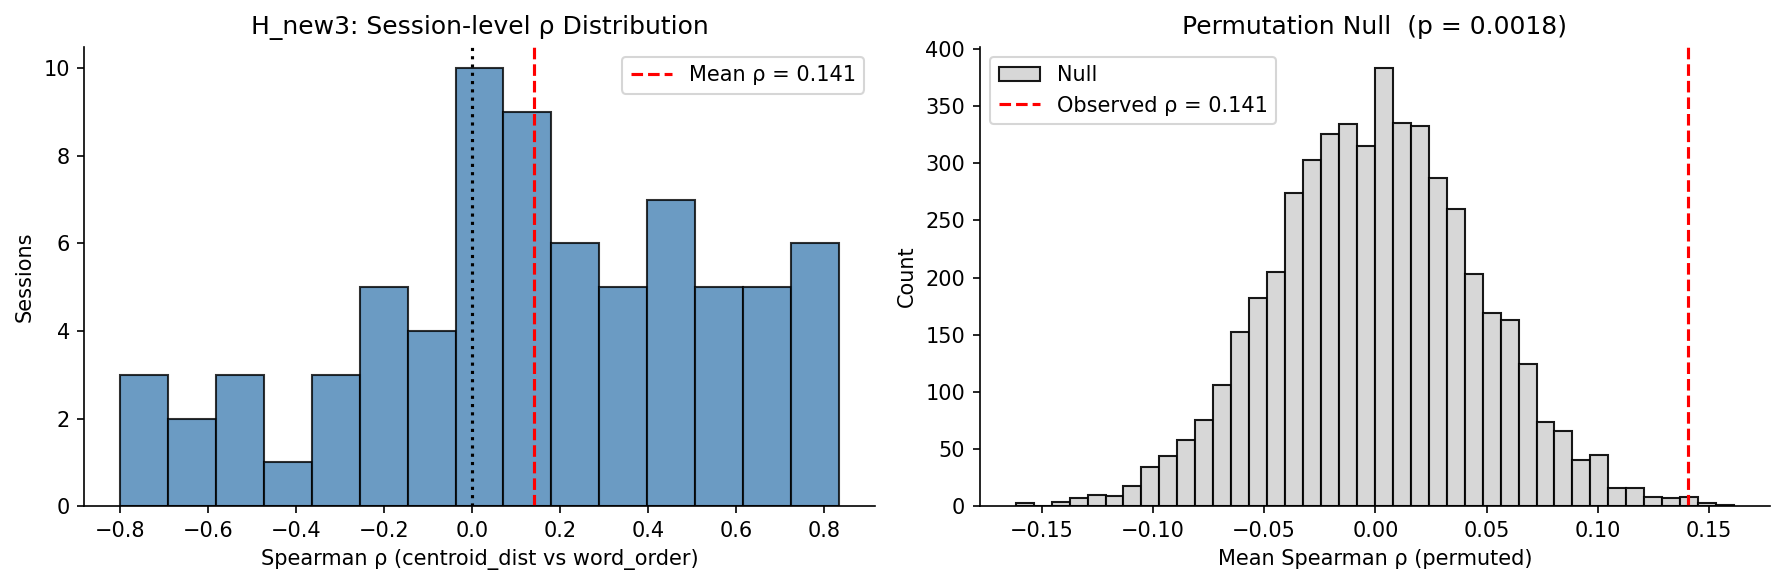


Plot saved → H_new3_SpAM_centroid.png


In [6]:
# ============================================================
# H_new3 — SpAM-central words retrieved earlier
# "Words closer to SpAM centroid tend to be recalled earlier"
#
# T1: One-sample Wilcoxon on Fisher-z(ρ) vs 0
# T2: Permutation test — shuffle word_order within session
#
# ρ = Spearman(centroid_dist, word_order) per session
# Positive ρ → central words (low dist) recalled earlier (low order) ✓
# ============================================================

import numpy as np
import pandas as pd
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

# ── 0. LOAD DATA ─────────────────────────────────────────────
vft  = pd.read_csv("/kaggle/input/datasets/suyashnpande/final-brsm-h1-new/final_vft_data.csv")
spam = pd.read_csv("/kaggle/input/datasets/suyashnpande/final-brsm-h1-new/final_spam_cordinates.csv")

# Normalise join keys (strip whitespace, lower-case domain)
for df in [vft, spam]:
    df["participant_id"] = df["participant_id"].astype(str).str.strip()
    df["domain"]         = df["domain"].str.strip().str.lower()
    df["word"]           = df["word"].str.strip()

# ── 1. COMPUTE CENTROID DISTANCE PER SESSION ─────────────────
def centroid_dist(grp):
    cx, cy = grp["x_norm"].mean(), grp["y_norm"].mean()
    grp = grp.copy()
    grp["centroid_dist"] = np.sqrt((grp["x_norm"] - cx)**2 +
                                   (grp["y_norm"] - cy)**2)
    return grp

spam = spam.groupby(["participant_id", "domain"], group_keys=False).apply(centroid_dist)

# ── 2. MERGE VFT × SpAM ON (participant, domain, word) ───────
merged = vft.merge(
    spam[["participant_id", "domain", "word", "centroid_dist"]],
    on=["participant_id", "domain", "word"],
    how="inner"
)
print(f"Merged rows : {len(merged)}")
print(f"Sessions    : {merged.groupby(['participant_id','domain']).ngroups}\n")

# ── 3. SPEARMAN ρ PER SESSION ─────────────────────────────────
def session_rho(grp):
    if len(grp) < 3:                     # need ≥3 pairs for Spearman
        return np.nan
    r, _ = stats.spearmanr(grp["centroid_dist"], grp["word_order"])
    return r

session_rhos = (
    merged.groupby(["participant_id", "domain"])
          .apply(session_rho)
          .dropna()
          .rename("rho")
          .reset_index()
)

n_sessions  = len(session_rhos)
mean_rho    = session_rhos["rho"].mean()
pct_positive = (session_rhos["rho"] > 0).mean() * 100

print(f"Sessions with valid ρ : {n_sessions}")
print(f"Mean Spearman ρ       : {mean_rho:.3f}")
print(f"Sessions with ρ > 0   : {pct_positive:.1f}%\n")

# ── 4. FISHER-Z TRANSFORM ────────────────────────────────────
# Fisher z = atanh(ρ), clips at ±0.9999 to avoid ±∞
rhos_clipped = session_rhos["rho"].clip(-0.9999, 0.9999)
fisher_z     = np.arctanh(rhos_clipped)

# ── 5. T1 — ONE-SAMPLE WILCOXON ON FISHER-Z ──────────────────
# H0: median Fisher-z = 0  (i.e., no systematic positive bias)
# H1: median Fisher-z > 0  (one-tailed, directional)
stat_T1, p_T1_two = stats.wilcoxon(fisher_z, alternative="two-sided")
stat_T1, p_T1_one = stats.wilcoxon(fisher_z, alternative="greater")

print("=" * 55)
print("T1 — One-sample Wilcoxon (Fisher-z vs 0)")
print("=" * 55)
print(f"  Statistic  : {stat_T1:.3f}")
print(f"  p (two-sided): {p_T1_two:.4f}")
print(f"  p (one-sided, ρ>0): {p_T1_one:.4f}")
sig = "✓ SIGNIFICANT" if p_T1_one < 0.05 else "✗ not significant"
print(f"  α = 0.05   → {sig}\n")

# ── 6. T2 — PERMUTATION TEST ─────────────────────────────────
# Null: shuffle word_order within each session, recompute mean ρ
# Observed statistic: mean Spearman ρ across all sessions

observed_stat = mean_rho
N_PERM        = 5000
rng           = np.random.default_rng(42)

perm_stats = np.empty(N_PERM)

for i in range(N_PERM):
    perm_data = merged.copy()
    # Shuffle word_order within each (participant, domain) session
    perm_data["word_order"] = (
        perm_data.groupby(["participant_id", "domain"])["word_order"]
                 .transform(lambda x: rng.permutation(x.values))
    )
    perm_rhos = (
        perm_data.groupby(["participant_id", "domain"])
                 .apply(session_rho)
                 .dropna()
    )
    perm_stats[i] = perm_rhos.mean()

# One-tailed p: proportion of null distribution >= observed
p_T2 = (perm_stats >= observed_stat).mean()

print("=" * 55)
print(f"T2 — Permutation Test  (N = {N_PERM} permutations)")
print("=" * 55)
print(f"  Observed mean ρ : {observed_stat:.4f}")
print(f"  Null mean ρ     : {perm_stats.mean():.4f}  ± {perm_stats.std():.4f}")
print(f"  p (one-tailed)  : {p_T2:.4f}")
sig2 = "✓ SIGNIFICANT" if p_T2 < 0.05 else "✗ not significant"
print(f"  α = 0.05        → {sig2}\n")

# ── 7. SUMMARY ───────────────────────────────────────────────
print("=" * 55)
print("SUMMARY — H_new3")
print("=" * 55)
print(f"  Sessions analysed  : {n_sessions}")
print(f"  Mean Spearman ρ    : {mean_rho:.3f}")
print(f"  % sessions ρ > 0   : {pct_positive:.1f}%")
print(f"  T1 Wilcoxon p (1-tail): {p_T1_one:.4f}")
print(f"  T2 Permutation p      : {p_T2:.4f}")

if p_T1_one < 0.05 and p_T2 < 0.05:
    verdict = "SUPPORTED — SpAM-central words retrieved significantly earlier."
elif p_T1_one < 0.05 or p_T2 < 0.05:
    verdict = "PARTIALLY SUPPORTED — one test significant, interpret cautiously."
else:
    verdict = "NOT SUPPORTED — no significant centroid-retrieval advantage."
print(f"\n  Verdict: {verdict}")

# ── 8. OPTIONAL PLOT ─────────────────────────────────────────
try:
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # (a) Distribution of session ρ values
    axes[0].hist(session_rhos["rho"], bins=15, edgecolor="black",
                 color="steelblue", alpha=0.8)
    axes[0].axvline(mean_rho, color="red", linestyle="--",
                    label=f"Mean ρ = {mean_rho:.3f}")
    axes[0].axvline(0, color="black", linestyle=":")
    axes[0].set_xlabel("Spearman ρ (centroid_dist vs word_order)")
    axes[0].set_ylabel("Sessions")
    axes[0].set_title("H_new3: Session-level ρ Distribution")
    axes[0].legend()

    # (b) Permutation null distribution
    axes[1].hist(perm_stats, bins=40, edgecolor="black",
                 color="lightgrey", alpha=0.9, label="Null")
    axes[1].axvline(observed_stat, color="red", linestyle="--",
                    label=f"Observed ρ = {observed_stat:.3f}")
    axes[1].set_xlabel("Mean Spearman ρ (permuted)")
    axes[1].set_ylabel("Count")
    axes[1].set_title(f"Permutation Null  (p = {p_T2:.4f})")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig("H_new3_SpAM_centroid.png", dpi=150)
    plt.show()
    print("\nPlot saved → H_new3_SpAM_centroid.png")
except Exception as e:
    print(f"Plot skipped: {e}")

# H4_new

SpAM words clustered: 682
Cluster-size distribution:
count    682.00
mean       4.06
std        2.06
min        1.00
25%        3.00
50%        4.00
75%        5.00
max       11.00
Name: cluster_size, dtype: float64

Item-level observations : 635
Participants            : 25
Domains                 : 4
Cluster-size range      : 1 – 11

T1-A — Item-level Spearman ρ  (cluster_size vs IRT)
  ρ = -0.264   p = 0.0000   N = 635 items
  ✓ SIGNIFICANT   ✓ correct direction (−)

T1-B — Per-participant ρ → Wilcoxon on Fisher-z
  Participants with valid ρ : 25
  Mean Spearman ρ           : -0.082
  % participants with ρ < 0 : 64.0%
  Wilcoxon statistic        : 98.000
  p (two-sided)             : 0.0851
  p (one-sided, ρ < 0)      : 0.0426
  α = 0.05  →  ✓ SIGNIFICANT

T2 — Mixed Model: log(IRT) ~ cluster_size + domain
     Random intercept: participant_id
                     Mixed Linear Model Regression Results
Model:                     MixedLM          Dependent Variable:          log_IRT
N

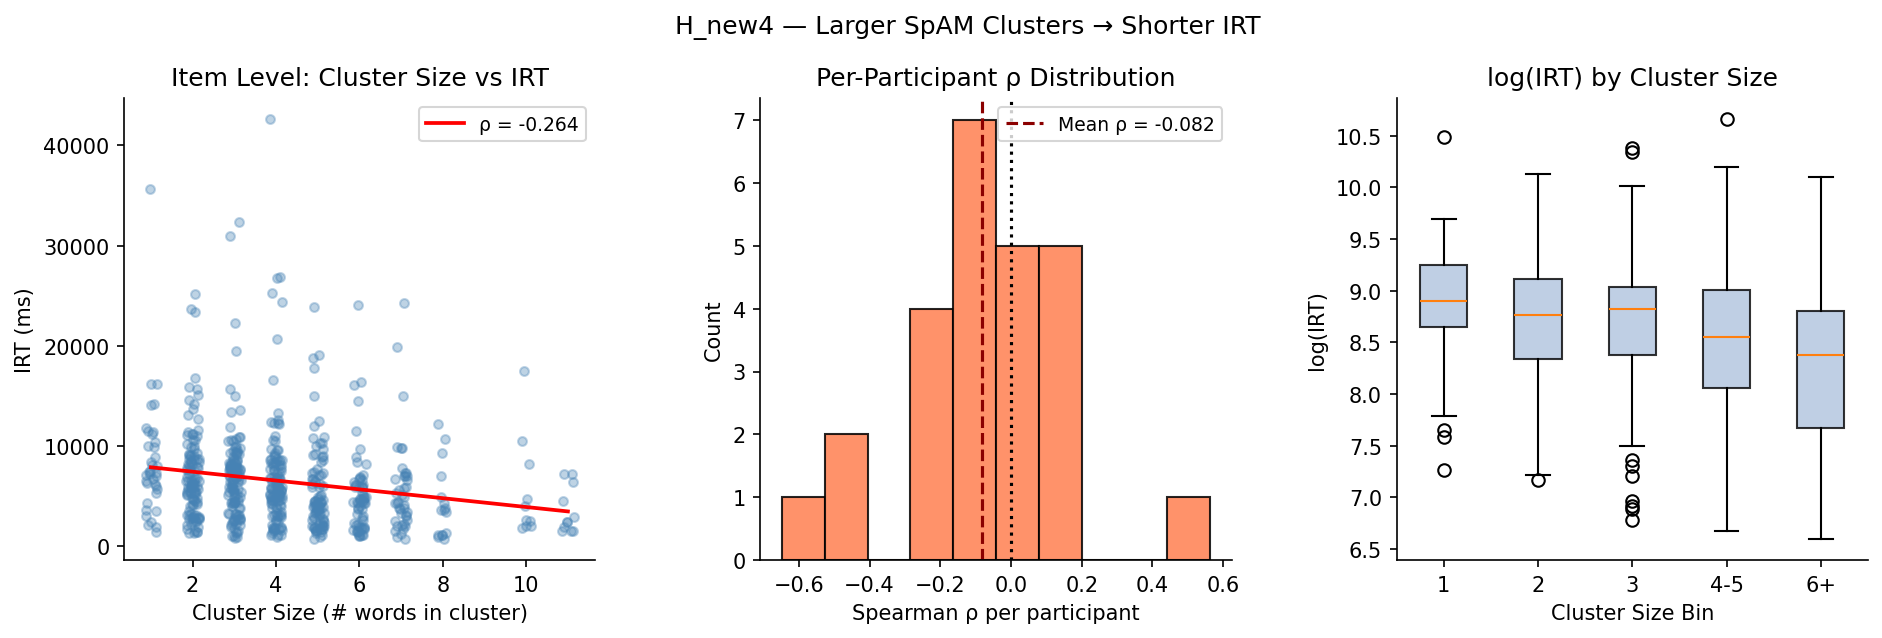


Plot saved → H_new4_cluster_IRT.png


In [8]:
# ============================================================
# H_new4 — Larger clusters searched faster, not slower
# "Words in bigger SpAM clusters have shorter IRTs"
#
# T1: Spearman ρ (cluster_size vs IRT) at item level
#     + per-participant Fisher-z Wilcoxon
# T2: Mixed model  log(IRT) ~ cluster_size + (1|participant) + (1|domain)
#
# ρ expected: negative (bigger cluster → shorter IRT)
# ============================================================

import numpy as np
import pandas as pd
from scipy import stats
from sklearn.cluster import AgglomerativeClustering
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings("ignore")

# ── 0. LOAD DATA ─────────────────────────────────────────────
vft  = pd.read_csv("/kaggle/input/datasets/suyashnpande/final-brsm-h1-new/final_vft_data.csv")
spam = pd.read_csv("/kaggle/input/datasets/suyashnpande/final-brsm-h1-new/final_spam_cordinates.csv")

for df in [vft, spam]:
    df["participant_id"] = df["participant_id"].astype(str).str.strip()
    df["domain"]         = df["domain"].str.strip().str.lower()
    df["word"]           = df["word"].str.strip()

# ── 1. CLUSTER WORDS WITHIN EACH SpAM SESSION ────────────────
# Uses Agglomerative (Ward linkage) with a distance threshold.
# DIST_THRESHOLD: words within this Euclidean distance (on 0-1
# normalised canvas) are grouped together. Tune if needed.
DIST_THRESHOLD = 0.30

def assign_clusters(grp):
    """Return group with cluster_id and cluster_size columns."""
    coords = grp[["x_norm", "y_norm"]].values
    n      = len(coords)

    if n == 1:
        grp = grp.copy()
        grp["cluster_id"]   = 0
        grp["cluster_size"] = 1
        return grp

    # Need at least 2 samples for clustering
    n_clusters_max = max(1, n - 1)

    try:
        model = AgglomerativeClustering(
            n_clusters       = None,
            distance_threshold = DIST_THRESHOLD,
            metric           = "euclidean",
            linkage          = "ward"
        )
        labels = model.fit_predict(coords)
    except Exception:
        # Fallback: treat everything as one cluster
        labels = np.zeros(n, dtype=int)

    grp = grp.copy()
    grp["cluster_id"] = labels

    # cluster_size = number of words in the same cluster (within session)
    size_map           = grp.groupby("cluster_id")["cluster_id"].transform("count")
    grp["cluster_size"] = size_map.values
    return grp

spam = spam.groupby(
    ["participant_id", "domain"], group_keys=False
).apply(assign_clusters)

print(f"SpAM words clustered: {len(spam)}")
print(f"Cluster-size distribution:\n{spam['cluster_size'].describe().round(2)}\n")

# ── 2. MERGE VFT × SpAM ──────────────────────────────────────
merged = vft.merge(
    spam[["participant_id", "domain", "word", "cluster_size"]],
    on=["participant_id", "domain", "word"],
    how="inner"
)

# Drop rows with IRT ≤ 0 or NaN (first-word IRT is often unreliable)
merged = merged[merged["IRT"] > 0].dropna(subset=["IRT", "cluster_size"])
merged["log_IRT"] = np.log(merged["IRT"])

print(f"Item-level observations : {len(merged)}")
print(f"Participants            : {merged['participant_id'].nunique()}")
print(f"Domains                 : {merged['domain'].nunique()}")
print(f"Cluster-size range      : {merged['cluster_size'].min()} – {merged['cluster_size'].max()}\n")

# ── 3. T1-A: ITEM-LEVEL SPEARMAN ρ ───────────────────────────
rho_item, p_item = stats.spearmanr(merged["cluster_size"], merged["IRT"])

print("=" * 58)
print("T1-A — Item-level Spearman ρ  (cluster_size vs IRT)")
print("=" * 58)
print(f"  ρ = {rho_item:.3f}   p = {p_item:.4f}   N = {len(merged)} items")
sig_item = "✓ SIGNIFICANT" if p_item < 0.05 else "✗ not significant"
direction = "✓ correct direction (−)" if rho_item < 0 else "✗ unexpected direction (+)"
print(f"  {sig_item}   {direction}\n")

# ── 4. T1-B: PER-PARTICIPANT SPEARMAN → WILCOXON ─────────────
def participant_rho(grp):
    if len(grp) < 3:
        return np.nan
    r, _ = stats.spearmanr(grp["cluster_size"], grp["IRT"])
    return r

part_rhos = (
    merged.groupby("participant_id")
          .apply(participant_rho)
          .dropna()
          .rename("rho")
          .reset_index()
)

n_part        = len(part_rhos)
mean_part_rho = part_rhos["rho"].mean()
pct_neg       = (part_rhos["rho"] < 0).mean() * 100

# Fisher-z transform, then one-sample Wilcoxon vs 0
fisher_z          = np.arctanh(part_rhos["rho"].clip(-0.9999, 0.9999))
stat_wil, p_wil2  = stats.wilcoxon(fisher_z, alternative="two-sided")
stat_wil, p_wil1  = stats.wilcoxon(fisher_z, alternative="less")   # expect ρ < 0

print("=" * 58)
print("T1-B — Per-participant ρ → Wilcoxon on Fisher-z")
print("=" * 58)
print(f"  Participants with valid ρ : {n_part}")
print(f"  Mean Spearman ρ           : {mean_part_rho:.3f}")
print(f"  % participants with ρ < 0 : {pct_neg:.1f}%")
print(f"  Wilcoxon statistic        : {stat_wil:.3f}")
print(f"  p (two-sided)             : {p_wil2:.4f}")
print(f"  p (one-sided, ρ < 0)      : {p_wil1:.4f}")
sig_wil = "✓ SIGNIFICANT" if p_wil1 < 0.05 else "✗ not significant"
print(f"  α = 0.05  →  {sig_wil}\n")

# ── 5. T2: MIXED MODEL  log(IRT) ~ cluster_size + (1|pid) + (1|domain)
# statsmodels MixedLM handles one grouping variable natively.
# We include domain as a fixed effect to partial out domain variance,
# then specify participant as the random-intercept grouping.
# This approximates the full crossed random-effects model.
print("=" * 58)
print("T2 — Mixed Model: log(IRT) ~ cluster_size + domain")
print("     Random intercept: participant_id")
print("=" * 58)

# Encode domain as categorical (reference = first alphabetically)
merged["domain_cat"] = pd.Categorical(merged["domain"])

try:
    lme = smf.mixedlm(
        "log_IRT ~ cluster_size + C(domain)",
        data   = merged,
        groups = merged["participant_id"]
    ).fit(reml=True, method="lbfgs")

    # Extract cluster_size coefficient
    cs_coef  = lme.params["cluster_size"]
    cs_se    = lme.bse["cluster_size"]
    cs_z     = lme.tvalues["cluster_size"]
    cs_p     = lme.pvalues["cluster_size"]
    cs_ci    = lme.conf_int().loc["cluster_size"]

    print(lme.summary())
    print()
    print("  ── cluster_size focal result ──")
    print(f"  β  = {cs_coef:.4f}  (SE = {cs_se:.4f})")
    print(f"  z  = {cs_z:.3f}   p = {cs_p:.4f}")
    print(f"  95% CI: [{cs_ci[0]:.4f}, {cs_ci[1]:.4f}]")
    sig_lme = "✓ SIGNIFICANT" if cs_p < 0.05 else "✗ not significant"
    dir_lme = "✓ β < 0 (faster IRT)" if cs_coef < 0 else "✗ β > 0 (unexpected)"
    print(f"  {sig_lme}   {dir_lme}")

except Exception as e:
    print(f"  Mixed model failed: {e}")
    print("  → Falling back to OLS with participant + domain fixed effects")
    ols = smf.ols(
        "log_IRT ~ cluster_size + C(domain) + C(participant_id)",
        data=merged
    ).fit()
    cs_coef = ols.params["cluster_size"]
    cs_p    = ols.pvalues["cluster_size"]
    print(f"  OLS β = {cs_coef:.4f}   p = {cs_p:.4f}")
    print(ols.summary())

# ── 6. SUMMARY ───────────────────────────────────────────────
print()
print("=" * 58)
print("SUMMARY — H_new4")
print("=" * 58)
print(f"  Items analysed             : {len(merged)}")
print(f"  Item-level ρ               : {rho_item:.3f}   p = {p_item:.4f}")
print(f"  Per-participant mean ρ      : {mean_part_rho:.3f}")
print(f"  % participants ρ < 0        : {pct_neg:.1f}%")
print(f"  Wilcoxon p (1-tail, ρ<0)   : {p_wil1:.4f}")
try:
    print(f"  Mixed model β (cluster_size): {cs_coef:.4f}   p = {cs_p:.4f}")
except:
    pass

both_sig = p_item < 0.05 and p_wil1 < 0.05
if both_sig and rho_item < 0:
    verdict = "SUPPORTED — larger SpAM clusters → shorter IRT (counter-intuitive)."
elif p_item < 0.05 or p_wil1 < 0.05:
    verdict = "PARTIALLY SUPPORTED — check mixed model for confirmation."
else:
    verdict = "NOT SUPPORTED — no significant cluster-size advantage."
print(f"\n  Verdict: {verdict}")

# ── 7. PLOTS ─────────────────────────────────────────────────
try:
    import matplotlib.pyplot as plt
    import matplotlib.gridspec as gridspec

    fig = plt.figure(figsize=(15, 4))
    gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

    # (a) Scatter: cluster_size vs IRT (jittered x)
    ax0 = fig.add_subplot(gs[0])
    jitter = np.random.default_rng(0).uniform(-0.15, 0.15, len(merged))
    ax0.scatter(merged["cluster_size"] + jitter, merged["IRT"],
                alpha=0.35, s=18, color="steelblue")
    # Trend line via linear regression on ranks (Spearman)
    from scipy.stats import mstats
    xs = merged["cluster_size"].values
    ys = merged["IRT"].values
    m, b = np.polyfit(xs, ys, 1)
    xline = np.linspace(xs.min(), xs.max(), 100)
    ax0.plot(xline, m * xline + b, color="red", lw=1.8,
             label=f"ρ = {rho_item:.3f}")
    ax0.set_xlabel("Cluster Size (# words in cluster)")
    ax0.set_ylabel("IRT (ms)")
    ax0.set_title("Item Level: Cluster Size vs IRT")
    ax0.legend(fontsize=9)

    # (b) Per-participant ρ distribution
    ax1 = fig.add_subplot(gs[1])
    ax1.hist(part_rhos["rho"], bins=10, edgecolor="black",
             color="coral", alpha=0.85)
    ax1.axvline(mean_part_rho, color="darkred", linestyle="--",
                label=f"Mean ρ = {mean_part_rho:.3f}")
    ax1.axvline(0, color="black", linestyle=":")
    ax1.set_xlabel("Spearman ρ per participant")
    ax1.set_ylabel("Count")
    ax1.set_title("Per-Participant ρ Distribution")
    ax1.legend(fontsize=9)

    # (c) Box: log(IRT) by cluster_size bucket
    ax2 = fig.add_subplot(gs[2])
    bins   = [0, 1, 2, 3, 5, 99]
    labels = ["1", "2", "3", "4-5", "6+"]
    merged["cs_bin"] = pd.cut(merged["cluster_size"], bins=bins, labels=labels)
    groups = [grp["log_IRT"].values for _, grp in merged.groupby("cs_bin", observed=True)]
    ax2.boxplot(groups, labels=labels, patch_artist=True,
                boxprops=dict(facecolor="lightsteelblue", alpha=0.8))
    ax2.set_xlabel("Cluster Size Bin")
    ax2.set_ylabel("log(IRT)")
    ax2.set_title("log(IRT) by Cluster Size")

    plt.suptitle("H_new4 — Larger SpAM Clusters → Shorter IRT", fontsize=12, y=1.02)
    plt.savefig("H_new4_cluster_IRT.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("\nPlot saved → H_new4_cluster_IRT.png")
except Exception as e:
    print(f"Plot skipped: {e}")